# Credit Risk Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


## Business Understanding

### Latar Belakang
Industri perbankan dan lembaga keuangan menghadapi kesulitan dalam mengelola risiko kredit, yaitu kemungkinan peminjam gagal memenuhi kewajiban pembayaran pinjaman mereka (default). Kegagalan dalam mengidentifikasi peminjam berisiko tinggi dapat menyebabkan kerugian finansial

Di proyek ini saya akan membuat proyel credit scoring, yakni proses evaluasi kelayakan kredit seseorang berdasarkan data historis yang membantu lembaga keuangan membuat keputusan:

*   Apakah pinjaman layak diberikan?
*   Berapa suku bunga yang tepat?
*   Berapa limit kredit yang sesuai?
*   Seberapa besar risiko yang dapaty ditoleransi?


### Isi Dataset
Dataset ini mencatat informasi historis pinjaman dari 32.581 peminjam dengan 12 variabel profil, karakteristik, dan status pembayaran.


In [ ]:
df.info()

NameError: name 'df' is not defined

* `person_age` = Usia peminjam
* `person_income` = Pendapatan tahunan peminjam
* `person_home_ownership` = Kategorikal status kepemilikan rumah (RENT/MORTGAGE/OWN/OTHER)
* `person_emp_length` = Lama bekerja (tahun)
* `loan_intent` = Grade peminjam (A/B/C/D/E/F/G)
* `loan_amt` = Jumlah pinjaman
* `loan_int_race` = Suku bunga pinjaman (%)
* `loan_status` = Status pembayaran **0 : Tidak defaut, 1 : default**
* `loan_percent_income` = Ratio pinjaman terhadap pendapatan
* `cb_person_default_on_file` = Riwayat default historis (Y/ N)
* `cb_person_cred_hist_length` = Panjang riwayat kredit (tahun)



### Tujuan
1. Identifikasi pola, memahahi faktor yang mempengaruhi risiko default
2. Segmentasi peminjam, mengelompokkan peminjam berdasarkan profil risiko
3. Insight bisnis, rekomendasi berbasis data untuk kebijakan kredit
4. Mitigas risiko, membantu meminimalkan kerugian akibat gagal bayar



## Business Problems
1. Berapa tingkat default keseluruhan dan bagaimana distribusinya?
2. Faktor apa yang paling kuat berhubungan dengan risiko default?
3. Apakah grade pinjaman secara signifikan berhubungan dengan status default?
4. Tujuan pinjaman apa yang memiliki tingkat default tertinggi?
5. Bagaimana hubungan antara suku bunga dan risiko default?
6. Apakah riwayat default historis memprediksi default saat ini?
7. Bagaimana ratio pinjaman pendapatan (loan_percent_income) mempengaruhi risiko?
8. Segmen peminjam mana yang paling berisiko?
9. Kebijakan kredit seperti apa yang sebaiknya diterapkan berdasarkan temuan ini?

## Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, kruskal
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


### Temuan Missing Values

In [ ]:
df.isnull().sum()


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


### Distribusi Variabel Kategorikal

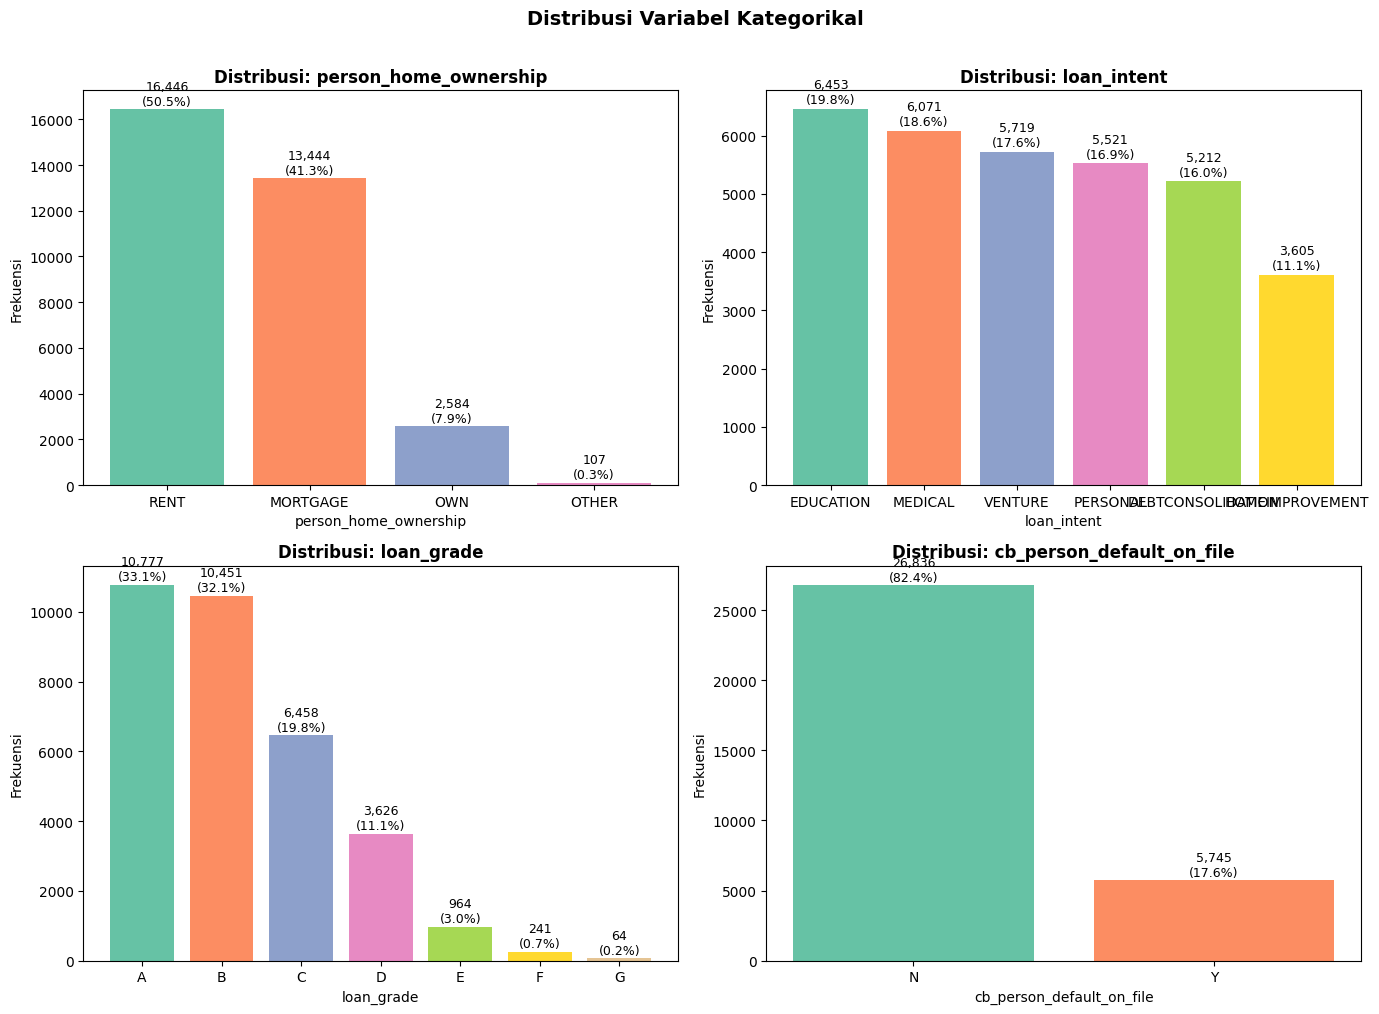


PERSON_HOME_OWNERSHIP:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107

LOAN_INTENT:
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605

LOAN_GRADE:
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64

CB_PERSON_DEFAULT_ON_FILE:
cb_person_default_on_file
N    26836
Y     5745


In [ ]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    bars = axes[i].bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)))
    axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                     f'{val:,}\n({val/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Ringkasan
for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts().to_string())


### Distribusi Target Variable (Loan Status)

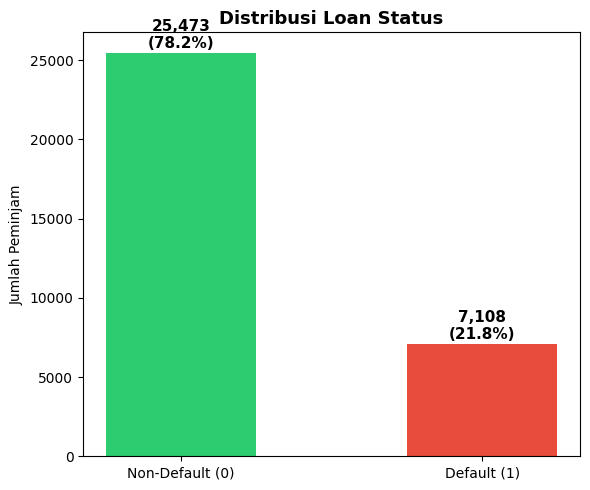

Total Peminjam  : 32,581
Non-Default (0) : 25,473 (78.18%)
Default (1)     : 7,108 (21.82%)
Tingkat Default : 21.82%


In [ ]:
status_count = df['loan_status'].value_counts()
labels = ['Non-Default (0)', 'Default (1)']
colors = ['#2ECC71', '#E74C3C']

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) # Changed to create only one subplot

# Bar Chart
bars = ax1.bar(labels, status_count.values, color=colors, width=0.5)
ax1.set_title('Distribusi Loan Status', fontsize=13, fontweight='bold')
ax1.set_ylabel('Jumlah Peminjam')
for bar, val in zip(bars, status_count.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}\n({val/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')



plt.tight_layout()
plt.show()

default_rate = df['loan_status'].mean() * 100
print(f"Total Peminjam  : {len(df):,}")
print(f"Non-Default (0) : {status_count[0]:,} ({status_count[0]/len(df)*100:.2f}%)")
print(f"Default (1)     : {status_count[1]:,} ({status_count[1]/len(df)*100:.2f}%)")
print(f"Tingkat Default : {default_rate:.2f}%")

## Data Cleaning
1. Deteksi & penghapusan duplikat
2. Penanganan outlier pada variabel numerik
3. Imputasi missing values

In [ ]:
df_original = df.copy()

### Drop duplikat

In [ ]:
df.duplicated().sum()

np.int64(165)

In [ ]:
df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

### Handle Outlier

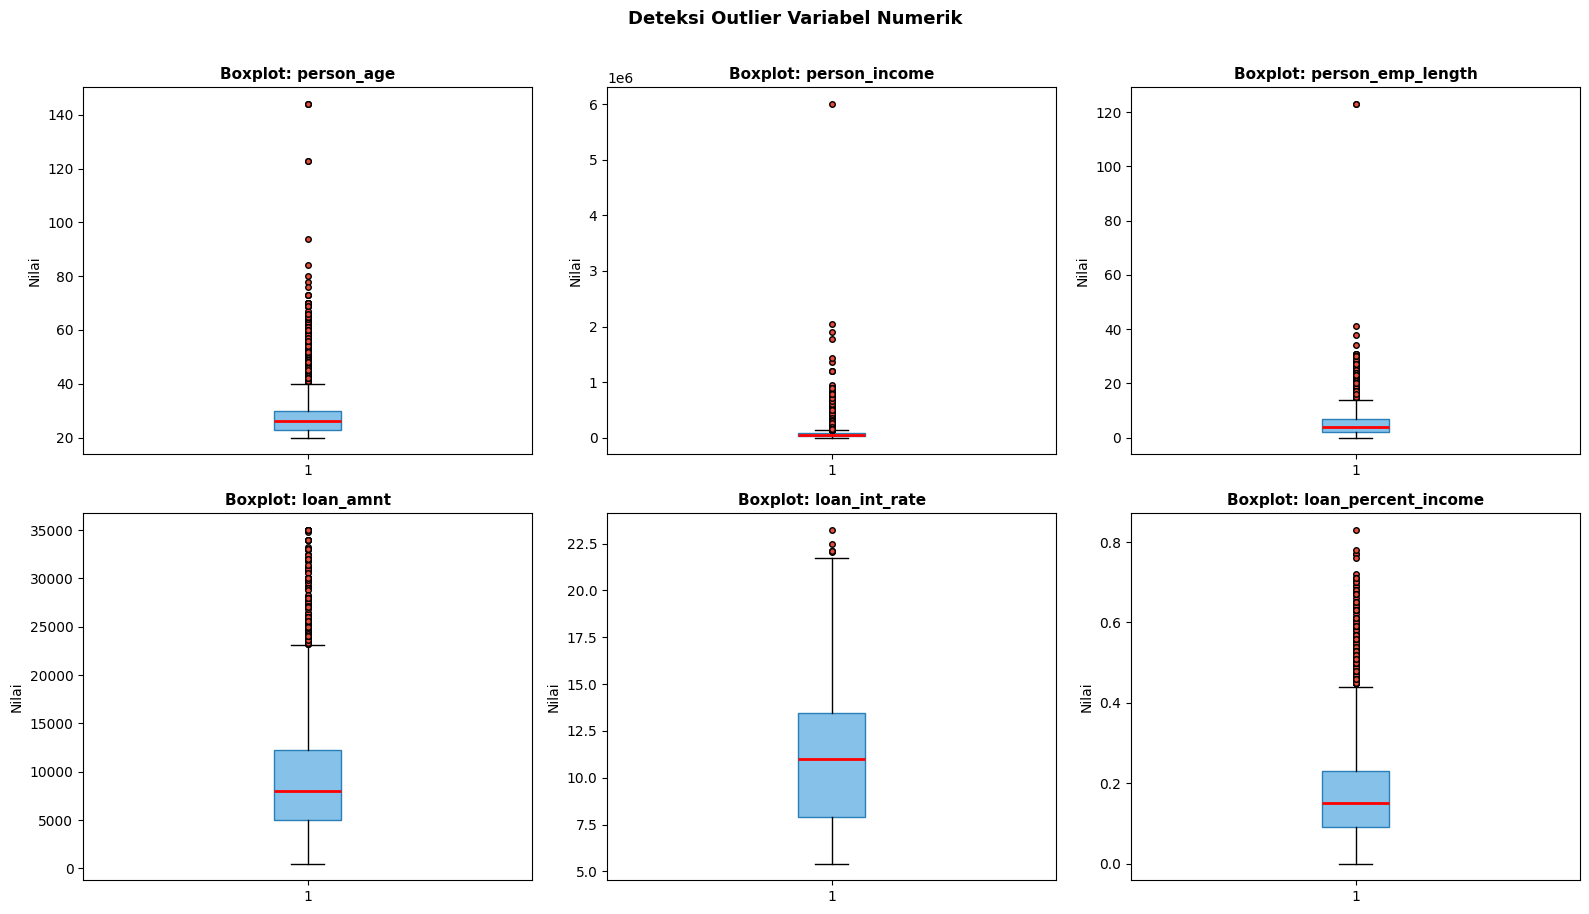


person_age:
   Q1=23.0, Q3=30.0, IQR=7.0
   Batas bawah=12.5, Batas atas=40.5
   Jumlah outlier: 1491 baris
   Nilai maksimum saat ini: 144

person_emp_length:
   Q1=2.0, Q3=7.0, IQR=5.0
   Batas bawah=-5.5, Batas atas=14.5
   Jumlah outlier: 852 baris
   Nilai maksimum saat ini: 123.0


In [ ]:
num_cols = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#85C1E9', color='#2980B9'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=4))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nilai')

plt.suptitle('Deteksi Outlier Variabel Numerik', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Statistik outlier
for col in ['person_age', 'person_emp_length']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"\n{col}:")
    print(f"   Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
    print(f"   Batas bawah={lower:.1f}, Batas atas={upper:.1f}")
    print(f"   Jumlah outlier: {n_out} baris")
    print(f"   Nilai maksimum saat ini: {df[col].max()}")

In [ ]:
# Delete outlier ekstrem
df.shape

(32416, 12)

In [ ]:
# person_age: nilai > 100 tidak realistis untuk peminjam
outlier_age = df[df['person_age'] > 100]


df = df[df['person_age'] <= 100].reset_index(drop=True)

# person_emp_length: nilai > 60 tidak realistis
outlier_emp = df[df['person_emp_length'] > 60]


df = df[df['person_emp_length'] <= 60].reset_index(drop=True)


In [ ]:
df.shape

(31522, 12)

### Handle Missing Values

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3027
loan_status,0
loan_percent_income,0


In [ ]:
# Handle loan_int_rate dengan median per loan_grade
# Suku bunga lebih representatif jika diisi dengan median berdasarkan grade pinjaman (suku bunga erat kaitannya dengan grade)


median_int_rate_by_grade = df.groupby('loan_grade')['loan_int_rate'].median()
print("\nMedian loan_int_rate per loan_grade:")
print(median_int_rate_by_grade.round(2))

df['loan_int_rate'] = df.apply(
    lambda row: median_int_rate_by_grade[row['loan_grade']]
                if pd.isnull(row['loan_int_rate']) else row['loan_int_rate'],
    axis=1
)

# person_emp_length: Imputasi dengan MEDIAN keseluruhan
median_emp = df['person_emp_length'].median()
print(f"\nMedian person_emp_length: {median_emp} tahun")
df['person_emp_length'].fillna(median_emp, inplace=True)



Median loan_int_rate per loan_grade:
loan_grade
A     7.49
B    10.99
C    13.48
D    15.31
E    16.77
F    18.53
G    20.16
Name: loan_int_rate, dtype: float64

Median person_emp_length: 4.0 tahun


## Feature Engineering
- `age_group` = Kelompok usia peminjam
- `income_group` = Kelompok pendapatan tahunan
- `loan_amnt_group` = Kategori jumlah peminjam
- `dti_category` = Kategori ratio utang pendapatan
- `loan_grade_num` = Numerisasi grade (A = 1 >> G = 7)
- `risk_score` = Skor risiko
- `risk_category` = Kategori risiko (Rendah/Sedang/Tinggi)

### Kelompok Usia (age_group)

In [ ]:
def assign_age_group(age):
    if age <= 25:
        return 'Muda (≤25)'
    elif age <= 35:
        return 'Dewasa (26-35)'
    elif age <= 50:
        return 'Paruh Baya (36-50)'
    else:
        return 'Senior (>50)'

df['age_group'] = df['person_age'].apply(assign_age_group)

print("Distribusi age_group:")
print(df['age_group'].value_counts())
print()
print("Default Rate per age_group:")
print(df.groupby('age_group')['loan_status'].mean().mul(100).round(2).astype(str) + '%')

Distribusi age_group:
age_group
Muda (≤25)            14789
Dewasa (26-35)        13366
Paruh Baya (36-50)     3088
Senior (>50)            279
Name: count, dtype: int64

Default Rate per age_group:
age_group
Dewasa (26-35)        20.43%
Muda (≤25)            22.89%
Paruh Baya (36-50)    20.08%
Senior (>50)          25.45%
Name: loan_status, dtype: object


### Kelompok Pendapatan (income_group)

In [ ]:
income_bins = [0, 30000, 60000, 100000, float('inf')]
income_labels = ['Rendah (<30K)', 'Menengah (30K-60K)', 'Tinggi (60K-100K)', 'Sangat Tinggi (>100K)']

df['income_group'] = pd.cut(df['person_income'],
                             bins=income_bins,
                             labels=income_labels,
                             right=False)

print("Distribusi income_group:")
print(df['income_group'].value_counts().sort_index())
print()
print("Default Rate per income_group:")
print(df.groupby('income_group', observed=True)['loan_status'].mean().mul(100).round(2))

Distribusi income_group:
income_group
Rendah (<30K)             3335
Menengah (30K-60K)       13554
Tinggi (60K-100K)        10126
Sangat Tinggi (>100K)     4507
Name: count, dtype: int64

Default Rate per income_group:
income_group
Rendah (<30K)            46.54
Menengah (30K-60K)       25.87
Tinggi (60K-100K)        13.27
Sangat Tinggi (>100K)     8.99
Name: loan_status, dtype: float64


### Kelompok Jumlah Pinjaman (loan_amnt_group)

In [ ]:
amnt_bins = [0, 5000, 15000, 25000, float('inf')]
amnt_labels = ['Kecil (<5K)', 'Menengah (5K-15K)', 'Besar (15K-25K)', 'Sangat Besar (>25K)']

df['loan_amnt_group'] = pd.cut(df['loan_amnt'],
                                bins=amnt_bins,
                                labels=amnt_labels,
                                right=False)

print("Distribusi loan_amnt_group:")
print(df['loan_amnt_group'].value_counts().sort_index())
print()
print("Default Rate per loan_amnt_group:")
print(df.groupby('loan_amnt_group', observed=True)['loan_status'].mean().mul(100).round(2))

Distribusi loan_amnt_group:
loan_amnt_group
Kecil (<5K)             7062
Menengah (5K-15K)      18141
Besar (15K-25K)         5080
Sangat Besar (>25K)     1239
Name: count, dtype: int64

Default Rate per loan_amnt_group:
loan_amnt_group
Kecil (<5K)            20.01
Menengah (5K-15K)      18.93
Besar (15K-25K)        29.49
Sangat Besar (>25K)    37.29
Name: loan_status, dtype: float64


### Kelompok DTI Ratio (dti_category)

In [ ]:
def assign_dti_category(ratio):
    if ratio < 0.10:
        return 'Sangat Rendah (<10%)'
    elif ratio < 0.20:
        return 'Rendah (10-20%)'
    elif ratio < 0.35:
        return 'Sedang (20-35%)'
    else:
        return 'Tinggi (≥35%)'

df['dti_category'] = df['loan_percent_income'].apply(assign_dti_category)

print("Distribusi dti_category:")
print(df['dti_category'].value_counts())
print()
print("Default Rate per dti_category:")
print(df.groupby('dti_category')['loan_status'].mean().mul(100).round(2))

Distribusi dti_category:
dti_category
Rendah (10-20%)         12149
Sangat Rendah (<10%)     8679
Sedang (20-35%)          8380
Tinggi (≥35%)            2314
Name: count, dtype: int64

Default Rate per dti_category:
dti_category
Rendah (10-20%)         14.44
Sangat Rendah (<10%)    11.52
Sedang (20-35%)         28.74
Tinggi (≥35%)           71.09
Name: loan_status, dtype: float64


### Numerisasi Loan Garde & Risk Score


In [ ]:
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['loan_grade_num'] = df['loan_grade'].map(grade_map)

print("Pemetaan loan_grade ke numerik:")
for k, v in grade_map.items():
    print(f"   Grade {k} menjadi {v}")

Pemetaan loan_grade ke numerik:
   Grade A menjadi 1
   Grade B menjadi 2
   Grade C menjadi 3
   Grade D menjadi 4
   Grade E menjadi 5
   Grade F menjadi 6
   Grade G menjadi 7


In [ ]:
# Normalisasi min-max tiap komponen ke skala 0-1
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

# Komponen skor (bobot dikalibrasi berdasarkan kepentingan bisnis):
#   - Grade numerik       : 40% (faktor terpenting)
#   - DTI ratio           : 30%
#   - Suku bunga          : 20%
#   - Riwayat default     : 10%
df['grade_norm']   = minmax(df['loan_grade_num'])           # 0=A, 1=G
df['dti_norm']     = minmax(df['loan_percent_income'])       # 0=rendah, 1=tinggi
df['intrate_norm'] = minmax(df['loan_int_rate'])             # 0=rendah, 1=tinggi
df['hist_default'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})  # 0=Tidak, 1=Ya

df['risk_score'] = (
    df['grade_norm']   * 40 +
    df['dti_norm']     * 30 +
    df['intrate_norm'] * 20 +
    df['hist_default'] * 10
).round(2)

# Kategori risiko
def assign_risk_category(score):
    if score < 25:
        return 'Rendah'
    elif score < 50:
        return 'Sedang'
    elif score < 70:
        return 'Tinggi'
    else:
        return 'Sangat Tinggi'

df['risk_category'] = df['risk_score'].apply(assign_risk_category)

print("Ringkasan Risk Score:")
print(df['risk_score'].describe().round(2))
print()
print("Distribusi risk_category:")
print(df['risk_category'].value_counts())
print()
print("Default Rate per risk_category:")
print(df.groupby('risk_category')['loan_status'].mean().mul(100).round(2).sort_values(ascending=False))

Ringkasan Risk Score:
count    31522.00
mean        22.43
std         14.61
min          0.36
25%          9.94
50%         19.05
75%         33.68
max         83.19
Name: risk_score, dtype: float64

Distribusi risk_category:
risk_category
Rendah           19951
Sedang           10154
Tinggi            1359
Sangat Tinggi       58
Name: count, dtype: int64

Default Rate per risk_category:
risk_category
Sangat Tinggi    91.38
Tinggi           70.57
Sedang           37.22
Rendah           10.10
Name: loan_status, dtype: float64


## Exploratory Data Analysis (EDA)

### Default Rate by Loan Grade

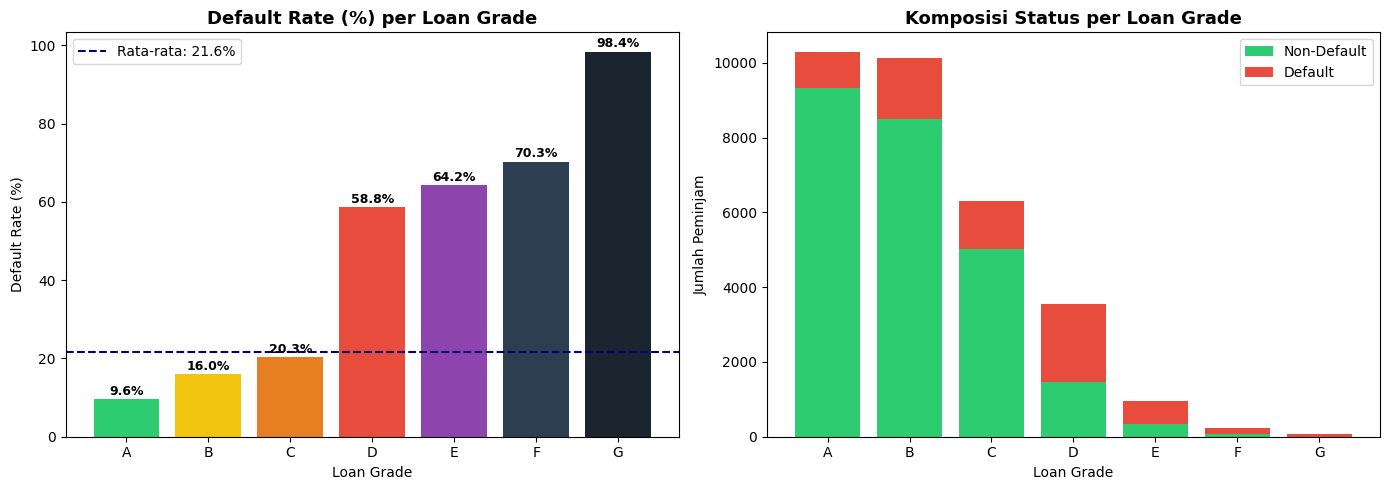


Detail Default Rate per Loan Grade:


,loan_grade,jumlah_peminjam,jumlah_default,default_rate
0,A,10300,985,9.56
1,B,10121,1616,15.97
2,C,6301,1280,20.31
3,D,3549,2086,58.78
4,E,951,611,64.25
5,F,236,166,70.34
6,G,64,63,98.44


In [ ]:
grade_analysis = df.groupby('loan_grade').agg(
    jumlah_peminjam=('loan_status', 'count'),
    jumlah_default=('loan_status', 'sum')
).reset_index()
grade_analysis['default_rate'] = (grade_analysis['jumlah_default'] / grade_analysis['jumlah_peminjam'] * 100).round(2)
grade_analysis['grade_num'] = grade_analysis['loan_grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})
grade_analysis = grade_analysis.sort_values('grade_num')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart default rate per grade
colors = ['#2ECC71','#F1C40F','#E67E22','#E74C3C','#8E44AD','#2C3E50','#1A252F']
bars = ax1.bar(grade_analysis['loan_grade'], grade_analysis['default_rate'], color=colors)
ax1.set_title('Default Rate (%) per Loan Grade', fontsize=13, fontweight='bold')
ax1.set_xlabel('Loan Grade')
ax1.set_ylabel('Default Rate (%)')
ax1.axhline(df['loan_status'].mean()*100, color='navy', linestyle='--', label=f"Rata-rata: {df['loan_status'].mean()*100:.1f}%")
ax1.legend()
for bar, val in zip(bars, grade_analysis['default_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Stacked bar
n_default = grade_analysis['jumlah_default']
n_nondefault = grade_analysis['jumlah_peminjam'] - n_default
ax2.bar(grade_analysis['loan_grade'], n_nondefault, label='Non-Default', color='#2ECC71')
ax2.bar(grade_analysis['loan_grade'], n_default, bottom=n_nondefault, label='Default', color='#E74C3C')
ax2.set_title('Komposisi Status per Loan Grade', fontsize=13, fontweight='bold')
ax2.set_xlabel('Loan Grade')
ax2.set_ylabel('Jumlah Peminjam')
ax2.legend()

plt.tight_layout()
plt.show()

print("\nDetail Default Rate per Loan Grade:")
display(grade_analysis[['loan_grade','jumlah_peminjam','jumlah_default','default_rate']])


Insight:

**Default rate naik secara konsisten dari grade A ke grade G.** Hal ini pertanda, bahwa sistem grading yang dipakai sudah berfungsi dengan benar dalam membedakan peminjam berisiko rendah dan tinggi.

**Ada lompatan besar yang tajam antara grade C dan grade D** dari 20,3 % langsung ke 58,8%. Menandakan kualitas peminjam turun drastis.

Grade D ke bawah perlu perlakuan khusus, karena risiko yang dibawa tidak lagi moderat tapi sudah masuk kategori ekstrem.



### Default Rate by Loan Intent


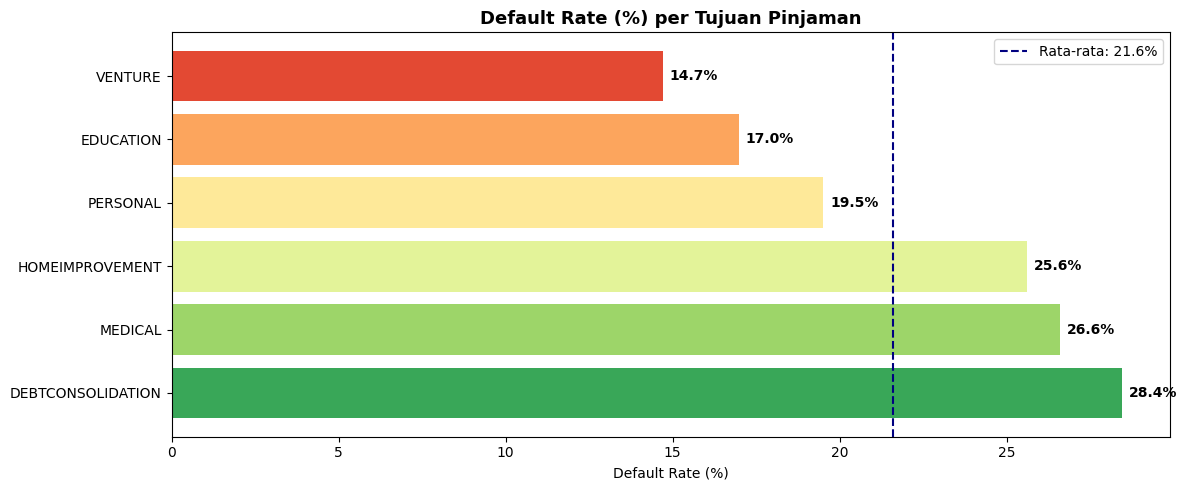


Detail Default Rate per Loan Intent:


,loan_intent,jumlah,default,default_rate,median_loan_amnt
0,DEBTCONSOLIDATION,5044,1435,28.45,8000.0
3,MEDICAL,5869,1561,26.60,8000.0
2,HOMEIMPROVEMENT,3499,896,25.61,9000.0
4,PERSONAL,5346,1043,19.51,8000.0
1,EDUCATION,6246,1061,16.99,8000.0
5,VENTURE,5518,811,14.70,8000.0


In [ ]:
intent_analysis = df.groupby('loan_intent').agg(
    jumlah=('loan_status', 'count'),
    default=('loan_status', 'sum')
).reset_index()
intent_analysis['default_rate'] = (intent_analysis['default'] / intent_analysis['jumlah'] * 100).round(2)

# median loan amount to intent_analysis
median_loan_amnt_by_intent = df.groupby('loan_intent')['loan_amnt'].median().reset_index()
median_loan_amnt_by_intent.rename(columns={'loan_amnt': 'median_loan_amnt'}, inplace=True)
intent_analysis = pd.merge(intent_analysis, median_loan_amnt_by_intent, on='loan_intent', how='left')

intent_analysis = intent_analysis.sort_values('default_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('RdYlGn_r', len(intent_analysis))
bars = ax.barh(intent_analysis['loan_intent'], intent_analysis['default_rate'], color=palette)
ax.set_title('Default Rate (%) per Tujuan Pinjaman', fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.axvline(df['loan_status'].mean()*100, color='navy', linestyle='--',
           label=f"Rata-rata: {df['loan_status'].mean()*100:.1f}%")
ax.legend()
for bar, val in zip(bars, intent_analysis['default_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetail Default Rate per Loan Intent:")
display(intent_analysis)

Insight:

**Debtconsolidation** paling berisiko dengan default rate 28,3%. Peminjam yang mengambil pinjaman untuk melunasi utang lain berarti sudah dalam kondisi finansial.

**Median pinjaman hampir identik di semua kategori 8.000 - 9.000**, artinya perbedaan default rate antar tujuan pinjaman bukan disebabkan perbedaan besar kecilnya pinjaman, tapi dari karakteristik dan kondisi finansial peminjam yang berbeda tujuan.

Kebijakan kredit tidak bisa seragam untuk semua tujuan pinjaman. Untuk tujuan Debt Consolidation dan Medical perlu evakuasi lebih ketat, karena konteks finansialnya lebih rentan.

### Default Rate by Home Ownership


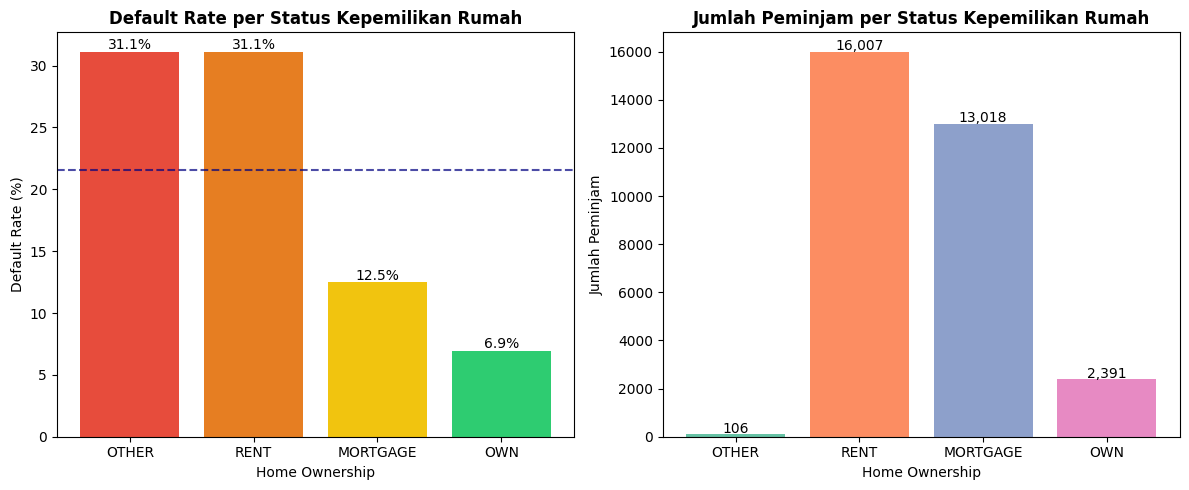


Detail Default Rate per Home Ownership:


,person_home_ownership,jumlah,default,default_rate
1,OTHER,106,33,31.13
3,RENT,16007,4981,31.12
0,MORTGAGE,13018,1627,12.50
2,OWN,2391,166,6.94


In [ ]:
home_analysis = df.groupby('person_home_ownership').agg(
    jumlah=('loan_status','count'),
    default=('loan_status','sum')
).reset_index()
home_analysis['default_rate'] = (home_analysis['default'] / home_analysis['jumlah'] * 100).round(2)
home_analysis = home_analysis.sort_values('default_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Chart
colors_home = ['#E74C3C','#E67E22','#F1C40F','#2ECC71']
bars = axes[0].bar(home_analysis['person_home_ownership'], home_analysis['default_rate'],
                   color=colors_home[:len(home_analysis)])
axes[0].set_title('Default Rate per Status Kepemilikan Rumah', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Home Ownership')
axes[0].set_ylabel('Default Rate (%)')
axes[0].axhline(df['loan_status'].mean()*100, color='navy', linestyle='--', alpha=0.7)
for bar, val in zip(bars, home_analysis['default_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=10)

# Volume Bar
axes[1].bar(home_analysis['person_home_ownership'], home_analysis['jumlah'],
            color=sns.color_palette('Set2', len(home_analysis)))
axes[1].set_title('Jumlah Peminjam per Status Kepemilikan Rumah', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Home Ownership')
axes[1].set_ylabel('Jumlah Peminjam')
for bar, val in zip(axes[1].patches, home_analysis['jumlah']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nDetail Default Rate per Home Ownership:")
display(home_analysis)

Insight:

**Mortgage adalah temuan paling menarik**. Peminjam yang sedang mencicil KPR punya default rate 12,5%, jauh lebih rendah dari rata-rata 21,5%, bahkan lebih rendah dari Grade B. Ini berlawanan dengan intuisi bahwa orang yang sudah punya utang KPR lebih berisiko. Artinya peminjam mortgage sudah tersaring lebih dulu oleh sistem kredit properti.

**Rent mewakili 50,7% dari seluruh peminjam**. Artinya setengah dari portofolio pinjaman ditanggung oleh kelompok dengan default rate tertinggi.

**Own hanya 7,6% dari total peminjam** tapi punya default rate terendah 6,9%. Segmen ini kecil dan mungkin tidak banyak yang membutuhkan pinjaman karena kondisi finansialnya sudah stabil.

Status kepemilikan rumah adalah sinyal risiko yang kuat dan mudah diverifikasi. Peminjam **rent** yang mengajukan pinjaman besar harus dievaluasi lebih ketat, sementara **mortgage**  bisa diperlakukan lebih longgar karena rekam jejak kredit mereka sudah teruji.

### Distribusi Pendapatan vs Loan Status

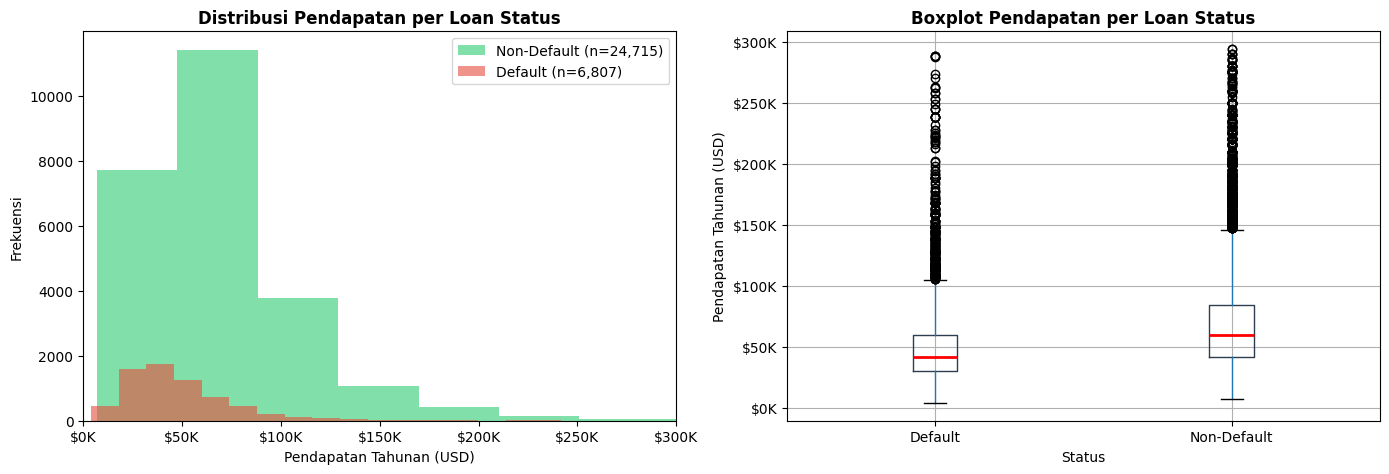

Statistik Pendapatan per Loan Status:


,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,24715.0,71066.0,55527.0,7000.0,42500.0,60000.0,85000.0,2039784.0
1,6807.0,49930.0,36634.0,4000.0,30000.0,42000.0,60000.0,703800.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi pendapatan
for status, label, color in zip([0, 1], ['Non-Default', 'Default'], ['#2ECC71','#E74C3C']):
    data = df[df['loan_status']==status]['person_income']
    axes[0].hist(data, bins=50, alpha=0.6, label=f'{label} (n={len(data):,})', color=color)
axes[0].set_title('Distribusi Pendapatan per Loan Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pendapatan Tahunan (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_xlim(0, 300000)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

# Boxplot
df_plot = df[df['person_income'] < 300000].copy()
df_plot['Status'] = df_plot['loan_status'].map({0:'Non-Default', 1:'Default'})
df_plot.boxplot(column='person_income', by='Status', ax=axes[1],
                boxprops=dict(color='#2C3E50'),
                medianprops=dict(color='red', linewidth=2),
                patch_artist=False)
axes[1].set_title('Boxplot Pendapatan per Loan Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pendapatan Tahunan (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Statistik Pendapatan per Loan Status:")
display(df.groupby('loan_status')['person_income'].describe().round(0))
#print(df.groupby('loan_status')['person_income'].describe().round(0))


Insight:

**Q1 non default lebih tinggi dari Q1 default**.Artinya peminjam non default yang paling rendah incomenya masih lebih tinggi, dari income peminjam default yang paling rendah incomenya.

**Adanya overlap yang besar**, Q3 peminjam default (60.000) = median non default (60.000). Artinya separuh peminjam non default punya income di bawah 60.000, sementara seperempat peminjam default punya income di atas 60.o00. Income tinggi tidak menjamin tidak default dan income rendah tidak otomatis menyebabkan default.

**Faktor income saja tidak cukup menjadi pertimbangan kebijakan kredit**. Seseorang dengan income 80.000 tapi meminjam 70.000 jauh lebih berisiko daripada seseorang dengan income 35.000 tapi hanya meminjam 3.000. Income harus selalu dievaluasi relatif terhadap jumlah pinjaman yang diajukan.

Jangan tolak atau setujui pinjaman berdasarkan income absolut. Selalu pasangkan dengan evaluasi jumlah pinjaman yang diajukan untuk mendapatkan gambaran risikonya.

### Distribusi Suku Bungan & Jumlah Pinjaman vs Loan Status

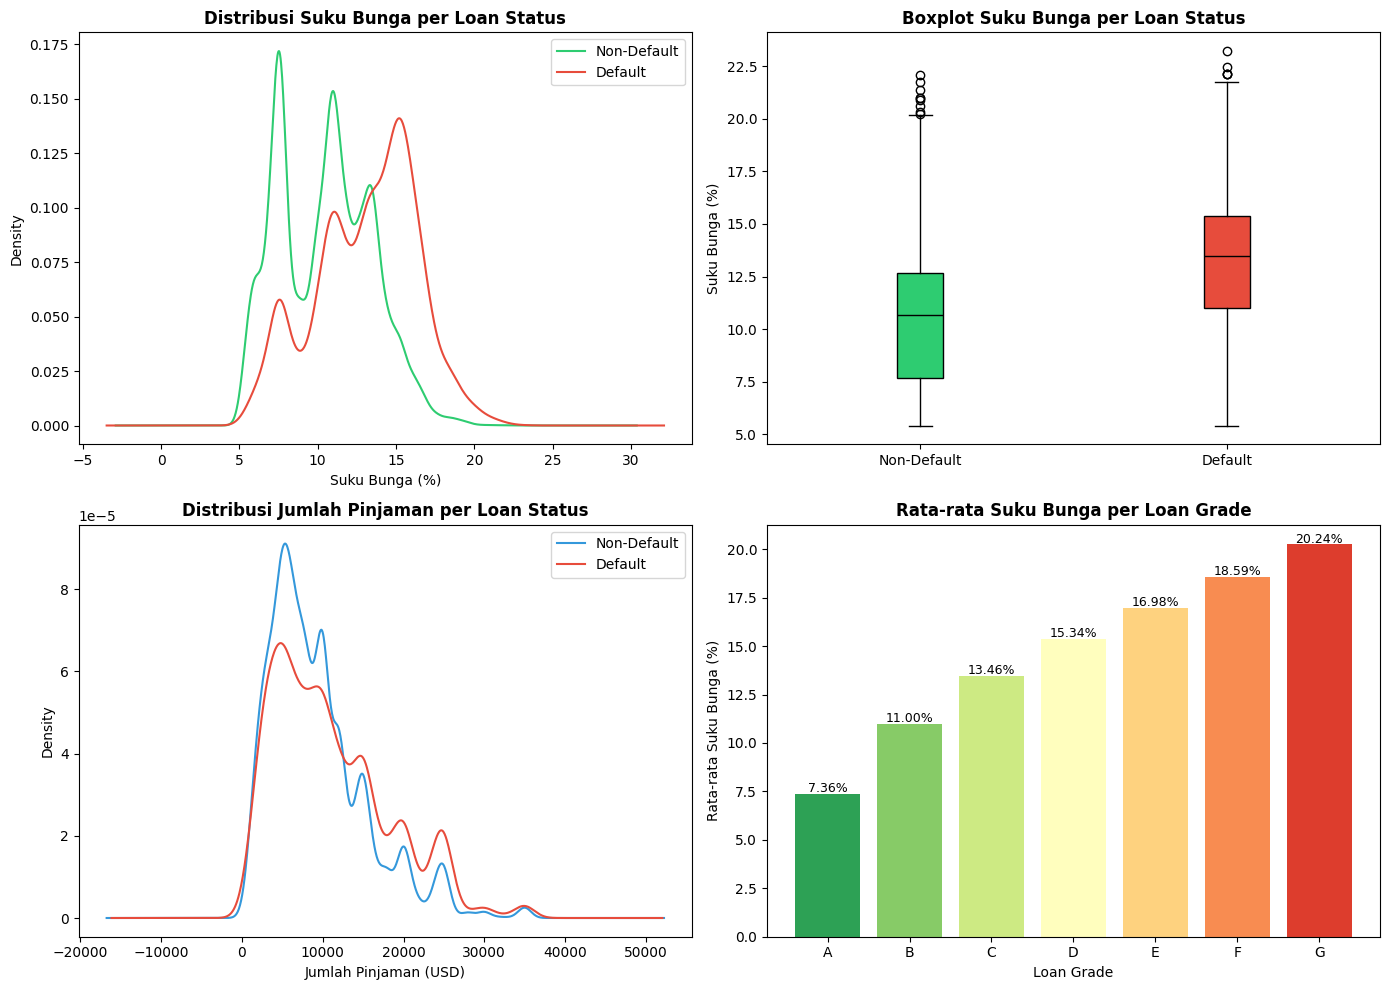

Statistik Suku Bunga per Loan Status:


,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,24715.0,10.48,2.95,5.42,7.66,10.65,12.69,22.06
1,6807.0,13.11,3.24,5.42,10.99,13.48,15.37,23.22



Statistik Jumlah Pinjaman per Loan Status:


,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
0,24715.0,9289.0,6036.0,500.0,5000.0,8000.0,12000.0,35000.0
1,6807.0,11023.0,7156.0,900.0,5000.0,10000.0,15000.0,35000.0



Statistik Rata-rata Suku Bunga per Loan Grade:


,loan_int_rate
loan_grade,
A,7.36
B,11.00
C,13.46
D,15.34
E,16.98
F,18.59
G,20.24


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. KDE suku bunga
for status, label, color in zip([0,1], ['Non-Default','Default'], ['#2ECC71','#E74C3C']):
    df[df['loan_status']==status]['loan_int_rate'].plot.kde(ax=axes[0,0], label=label, color=color)
axes[0,0].set_title('Distribusi Suku Bunga per Loan Status', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Suku Bunga (%)')
axes[0,0].legend()

# 2. Boxplot suku bunga
data_box = [df[df['loan_status']==0]['loan_int_rate'].dropna(),
            df[df['loan_status']==1]['loan_int_rate'].dropna()]
bp = axes[0,1].boxplot(data_box, labels=['Non-Default','Default'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#2ECC71','#E74C3C']):
    patch.set_facecolor(color)
bp['medians'][0].set_color('black'); bp['medians'][1].set_color('black')
axes[0,1].set_title('Boxplot Suku Bunga per Loan Status', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Suku Bunga (%)')

# 3. KDE jumlah pinjaman
for status, label, color in zip([0,1], ['Non-Default','Default'], ['#3498DB','#E74C3C']):
    df[df['loan_status']==status]['loan_amnt'].plot.kde(ax=axes[1,0], label=label, color=color)
axes[1,0].set_title('Distribusi Jumlah Pinjaman per Loan Status', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Jumlah Pinjaman (USD)')
axes[1,0].legend()

# 4. Mean per grade
mean_rate = df.groupby('loan_grade')['loan_int_rate'].mean().sort_index()
axes[1,1].bar(mean_rate.index, mean_rate.values, color=sns.color_palette('RdYlGn_r', len(mean_rate)))
axes[1,1].set_title('Rata-rata Suku Bunga per Loan Grade', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Loan Grade')
axes[1,1].set_ylabel('Rata-rata Suku Bunga (%)')
for i, (g, v) in enumerate(mean_rate.items()):
    axes[1,1].text(i, v+0.1, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print("Statistik Suku Bunga per Loan Status:")
display(df.groupby('loan_status')['loan_int_rate'].describe().round(2))
print("\nStatistik Jumlah Pinjaman per Loan Status:")
display(df.groupby('loan_status')['loan_amnt'].describe().round(0))
print("\nStatistik Rata-rata Suku Bunga per Loan Grade:")
display(df.groupby('loan_grade')['loan_int_rate'].mean().round(2))


Insight:
**Seluruh distribusi suku bunga peminjam default bergeser ke kanan secara konsisten**. Q1 peminjam default (10,9%) lebih tinggi dari median peminjam non default (10,65%). Artinya peminjam default yang paling murah bunganya pun setara dengan peminjam non default yang bunganya di titik tengah.

**Jumlah pinjaman default lebih besar tapi perbedaannya tidak sedrastis suku bunga**. Selisih median diantara besarnya hanya 2.000. Artinya jumlah pinjaman absolut bukan prediktor default yang kuat, yang penting bukan berapa besar pinjamannya, tapi seberapa besar pinjaman itu relatif terhadap pendapatan (DTI).

**Rata-rata suku bunga per grade naik sekitar 2% per grade**. Suku bunga naik secara konsisten dari Grade A ke Grade G, baik untuk peminjam default maupun non-default. Ini membuktikan bahwa sistem penetapan bunga sudah terkalibrasi dengan baik terhadap profil risiko grade.

Suku bunga di atas 13% bisa dijadikan early warning, peminjam yang mendapat suku bunga di atas angka ini masuk kelompok yang perlu monitoring lebih ketat, karena berisiko lebih tinggi dari rata-rata.


### Heatmap Korelasi
Korelasi setiap variabel dengan `loan_status`

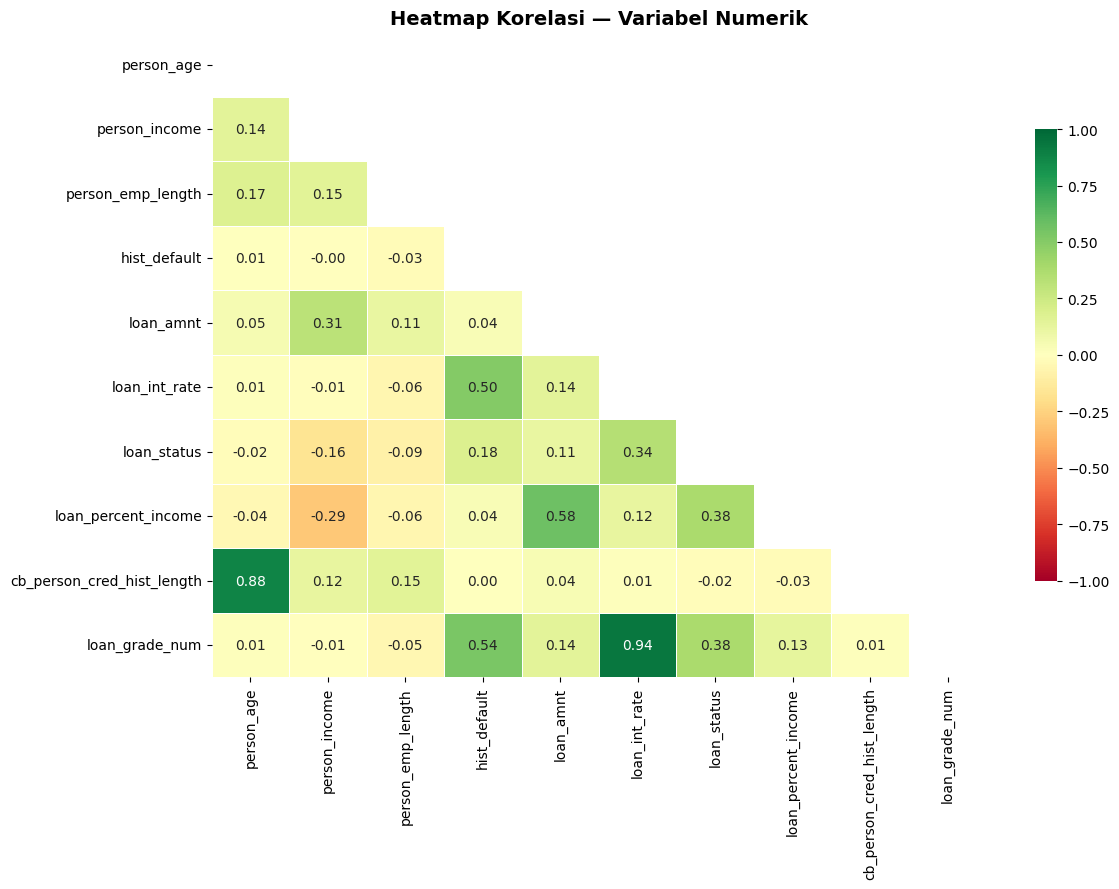


Korelasi dengan loan_status:
loan_percent_income           0.380
loan_grade_num                0.377
loan_int_rate                 0.338
hist_default                  0.181
person_income                 0.165
loan_amnt                     0.113
person_emp_length             0.086
person_age                    0.023
cb_person_cred_hist_length    0.018
Name: loan_status, dtype: float64


In [ ]:
num_features = ['person_age', 'person_income', 'person_emp_length', 'hist_default',
                'loan_amnt', 'loan_int_rate', 'loan_status',
                'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_num',]

corr_matrix = df[num_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
hm = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                 cmap='RdYlGn', center=0, vmin=-1, vmax=1,
                 ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.7})
ax.set_title('Heatmap Korelasi — Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi dengan loan_status:")
print(corr_matrix['loan_status'].drop('loan_status').abs().sort_values(ascending=False).round(3))

Insight:

**loan_percent_income (DTI) punya korelasi tertinggi dengan default**, bukan loan_grade_num. Selisihnya sangat tipis, tapi menarik karena artinya rasio beban utang terhadap pendapatan adalah prediktor default sedikit lebih kuat dibanding grade yang sudah ditetapkan lembaga keuangan sendiri. DTI mencerminkan **kemampuan bayar nyata**, sedangkan grade adalah penilaian yang dibuat sebelum pinjaman berjalan.

**Tiga variabel teratas (DTI, grade, suku bunga) hampir setara kekuatannya** dengan korelasi 0,33 - 0,38. Ini berarti tidak ada satu variabel tunggal yang dominan, model kredit yang baik harus mempertimbangkan ketiganya, bukan hanya satu.

**`hist_default` (riwayat default historis) berada di posisi keempat**. Kekuatannya cukup signifikan, riwayat default masa lalu memang bisa memprediksi default masa depan, meskipun bukan jaminan pasti.



### Risk Score Distribution

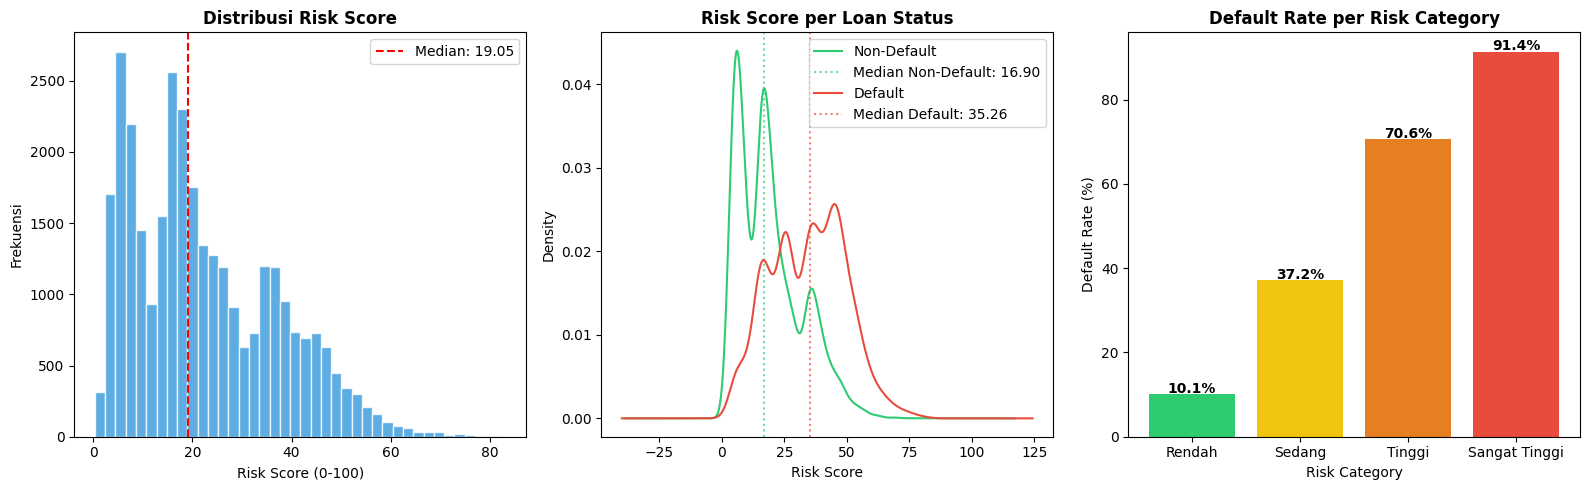


Default Rate per Risk Category:


,count,mean
risk_category,,
Rendah,19951,0.101
Sangat Tinggi,58,0.914
Sedang,10154,0.372
Tinggi,1359,0.706



Statistik Risk Score Keseluruhan


,min,max,mean,median
risk_score,0.36,83.19,22.43,19.05



Statistik Risk Score per Loan Status


,mean,median
loan_status,,
Non-Default,19.12,16.90
Default,34.46,35.26


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribusi risk score
axes[0].hist(df['risk_score'], bins=40, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribusi Risk Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk Score (0-100)')
axes[0].set_ylabel('Frekuensi')
overall_median_risk_score = df['risk_score'].median()
axes[0].axvline(overall_median_risk_score, color='red', linestyle='--', label=f'Median: {overall_median_risk_score:.2f}')
axes[0].legend()

# Risk score per loan status
for status, label, color in zip([0,1], ['Non-Default','Default'], ['#2ECC71','#E74C3C']):
    subset = df[df['loan_status']==status]['risk_score']
    subset.plot.kde(ax=axes[1], label=label, color=color)
    median_subset = subset.median()
    axes[1].axvline(median_subset, color=color, linestyle=':', alpha=0.7, label=f'Median {label}: {median_subset:.2f}')
axes[1].set_title('Risk Score per Loan Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].legend()

# Default rate per risk category
risk_cat_order = ['Rendah','Sedang','Tinggi','Sangat Tinggi']
risk_default = df.groupby('risk_category')['loan_status'].mean().mul(100).reindex(risk_cat_order)
colors_risk = ['#2ECC71','#F1C40F','#E67E22','#E74C3C']
bars = axes[2].bar(risk_default.index, risk_default.values, color=colors_risk)
axes[2].set_title('Default Rate per Risk Category', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Risk Category')
axes[2].set_ylabel('Default Rate (%)')
for bar, val in zip(bars, risk_default.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDefault Rate per Risk Category:")
display(df.groupby('risk_category')['loan_status'].agg(['count','mean']).round(3))

print('\nStatistik Risk Score Keseluruhan')
overall_risk_stats = df['risk_score'].describe().loc[['min', 'max', 'mean', '50%']].to_frame().T
overall_risk_stats.rename(columns={'50%': 'median'}, inplace=True)
display(overall_risk_stats.round(2))

print('\nStatistik Risk Score per Loan Status')
risk_by_status = df.groupby('loan_status')['risk_score'].agg(['mean', 'median'])
risk_by_status.index = risk_by_status.index.map({0: 'Non-Default', 1: 'Default'})
display(risk_by_status.round(2))

Insight:
**Distribusi risk_score sangat condong ke kiri**. Ini berarti mayoritas peminjam masuk kategori rendha dengan skor di bawah 25. Artinya portfolio kredit secara keseluruhan masih didominasi oleh peminjam yang profilnya baik.

**Gradasi default rate per kategori konsisten**. Tidak ada anomali atau lompatan tidak logis. Ini menandakan bahwa bobot yang dipilih (grade 40%, DTI 30%, suku bunga 20%, riwayat default 10%) sudha terkalibrasi dengan baik.

risk_score bisa diimplementasikan sebagai alat scoring otomatis. Ketika peminjam baru mengajukan pinjaman, sistem akan menghitung 4 komponen (grade, DTI, suku bunga, riwayat default) dan menghasilkan skor 0 - 100. Lalu menentukan kebijakan yang berlaku:
* Rendah = proses cepat
* Sedang = review standar
* Tinggi = perlu agunan dan review advanced
* Sangat Tinggi = tolak atau tawarkan produk alternatif



## Hypothesis Testing
Pengujian hipotesis dilakukan untuk memvalidasi apakah hubungan dan perbendaan yang terlihat dalam EDA secara statistik signifikan.
**Tingkat signifikansi: α = 0.05**
- Jika p-value < 0.05 → **Tolak H₀** (ada hubungan/perbedaan yang signifikan)
- Jika p-value ≥ 0.05 → **Gagal Tolak H₀** (tidak cukup bukti)


In [ ]:
hypothesis_results = []
ALPHA = 0.05

### H1 Chi Square Test : Loan Grade vs Loan Status
H0 : Tidak ada hubungan antara loan_grade dan loan_status

H1: Terdapat hubungan signifikan antara loan_grade dan loan_status

H1: Chi-Square Test — Loan Grade vs Loan Status
Contingency Table:


loan_status,0,1
loan_grade,,
A,9315,985
B,8505,1616
C,5021,1280
D,1463,2086
E,340,611
F,70,166
G,1,63



Chi-Square Statistic : 5550.2954
P-value              : 0.00e+00
Degrees of Freedom   : 6

Kesimpulan: ✅ TOLAK H₀
Terdapat hubungan yang SIGNIFIKAN antara grade pinjaman dan status default.
Peminjam dengan grade lebih rendah (D-G) memiliki risiko default jauh lebih tinggi.


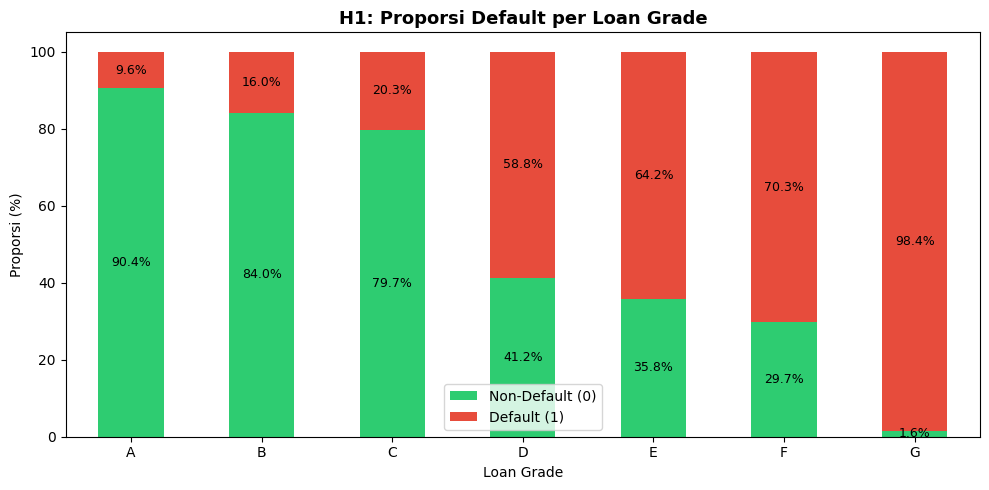

In [ ]:
ct1 = pd.crosstab(df['loan_grade'], df['loan_status'])
chi2_1, p1, dof1, expected1 = chi2_contingency(ct1)

print("=" * 60)
print("H1: Chi-Square Test — Loan Grade vs Loan Status")
print("=" * 60)
print(f"Contingency Table:")
display(ct1)
print(f"\nChi-Square Statistic : {chi2_1:.4f}")
print(f"P-value              : {p1:.2e}")
print(f"Degrees of Freedom   : {dof1}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p1 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p1 < ALPHA:
    print("Terdapat hubungan yang SIGNIFIKAN antara grade pinjaman dan status default.")
    print("Peminjam dengan grade lebih rendah (D-G) memiliki risiko default jauh lebih tinggi.")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
ct1_pct = ct1.div(ct1.sum(axis=1), axis=0) * 100
ct1_pct.plot(kind='bar', stacked=True, ax=ax,
             color=['#2ECC71','#E74C3C'], legend=True)
ax.set_title('H1: Proporsi Default per Loan Grade', fontsize=13, fontweight='bold')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Proporsi (%)')
ax.legend(['Non-Default (0)', 'Default (1)'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)
plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H1', 'Uji': 'Chi-Square',
    'Variabel': 'loan_grade vs loan_status',
    'Statistik': f'{chi2_1:.4f}', 'P-value': f'{p1:.2e}',
    'Keputusan': 'Tolak H₀' if p1 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p1 < ALPHA else 'Tidak'
})


**Tolak H0**, grade pinjaman terbukti berhubungan signifikan dengan default. Artinya sistem grading bank sudah berfungsi dengan baik sebagai prediktor risiko

### H2 Mann Whitney U : Pendapatan vs Loan Status
H0 : Distribusi pendapatan peminjam default = non default

H1 : Pendapatan peminjam default < non default (one tailed)

H2: Mann-Whitney U — Pendapatan vs Loan Status
Median Pendapatan Non-Default : $60,000
Median Pendapatan Default     : $42,000

Mann-Whitney U Statistic : 115492114.5000
P-value (one-tailed)     : 0.00e+00

Kesimpulan: ✅ TOLAK H₀
Pendapatan non-default secara signifikan LEBIH TINGGI dari default.
Selisih median pendapatan: $18,000


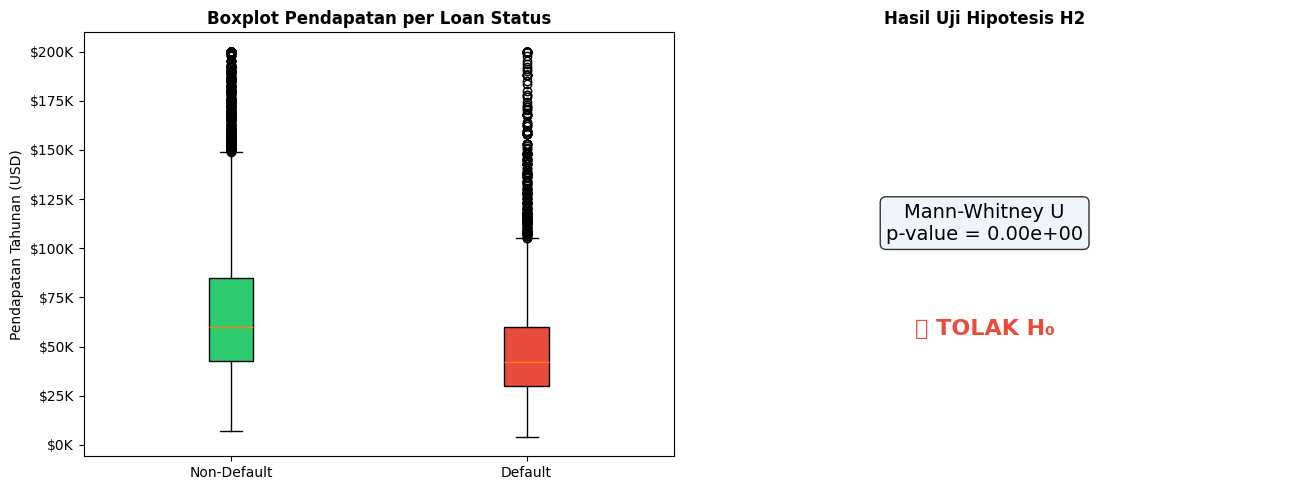

In [ ]:
income_default = df[df['loan_status']==1]['person_income']
income_nondefault = df[df['loan_status']==0]['person_income']

stat2, p2 = mannwhitneyu(income_nondefault, income_default, alternative='greater')

print("=" * 60)
print("H2: Mann-Whitney U — Pendapatan vs Loan Status")
print("=" * 60)
print(f"Median Pendapatan Non-Default : ${income_nondefault.median():,.0f}")
print(f"Median Pendapatan Default     : ${income_default.median():,.0f}")
print(f"\nMann-Whitney U Statistic : {stat2:.4f}")
print(f"P-value (one-tailed)     : {p2:.2e}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p2 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p2 < ALPHA:
    diff = income_nondefault.median() - income_default.median()
    print(f"Pendapatan non-default secara signifikan LEBIH TINGGI dari default.")
    print(f"Selisih median pendapatan: ${diff:,.0f}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
data_box2 = [income_nondefault.clip(upper=200000), income_default.clip(upper=200000)]
bp2 = axes[0].boxplot(data_box2, labels=['Non-Default','Default'], patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#2ECC71','#E74C3C']):
    patch.set_facecolor(color)
axes[0].set_title('Boxplot Pendapatan per Loan Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pendapatan Tahunan (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

axes[1].text(0.5, 0.55, f'Mann-Whitney U\np-value = {p2:.2e}', ha='center',
             va='center', fontsize=14, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#EAF2F8', alpha=0.8))
axes[1].text(0.5, 0.3, '✅ TOLAK H₀' if p2 < ALPHA else '❌ GAGAL TOLAK H₀',
             ha='center', va='center', fontsize=16, fontweight='bold',
             color='#E74C3C' if p2 < ALPHA else '#27AE60', transform=axes[1].transAxes)
axes[1].axis('off')
axes[1].set_title('Hasil Uji Hipotesis H2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H2', 'Uji': 'Mann-Whitney U',
    'Variabel': 'person_income vs loan_status',
    'Statistik': f'{stat2:.4f}', 'P-value': f'{p2:.2e}',
    'Keputusan': 'Tolak H₀' if p2 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p2 < ALPHA else 'Tidak'
})

**Tolak H0**, pendapatan peminjam non default secara statistik lebih tinggi dari yang default.

### H3 Spearnman Correlation (suku bunga vs loan_status)
H0 : Tidak ada korelasi antara suku bunga dan loan_status

H1 : Terdapat korelasi positif signifikan antara suku bunga dan loan_status

H3: Spearman Correlation — Suku Bunga vs Loan Status
Koefisien Spearman (ρ) : 0.3229
P-value                : 0.00e+00

Interpretasi kekuatan korelasi:
   |ρ| = 0.3229 → Korelasi Moderat Positif

Kesimpulan: ✅ TOLAK H₀
Terdapat korelasi positif SIGNIFIKAN antara suku bunga dan risiko default.
Semakin tinggi suku bunga, semakin tinggi kemungkinan default.


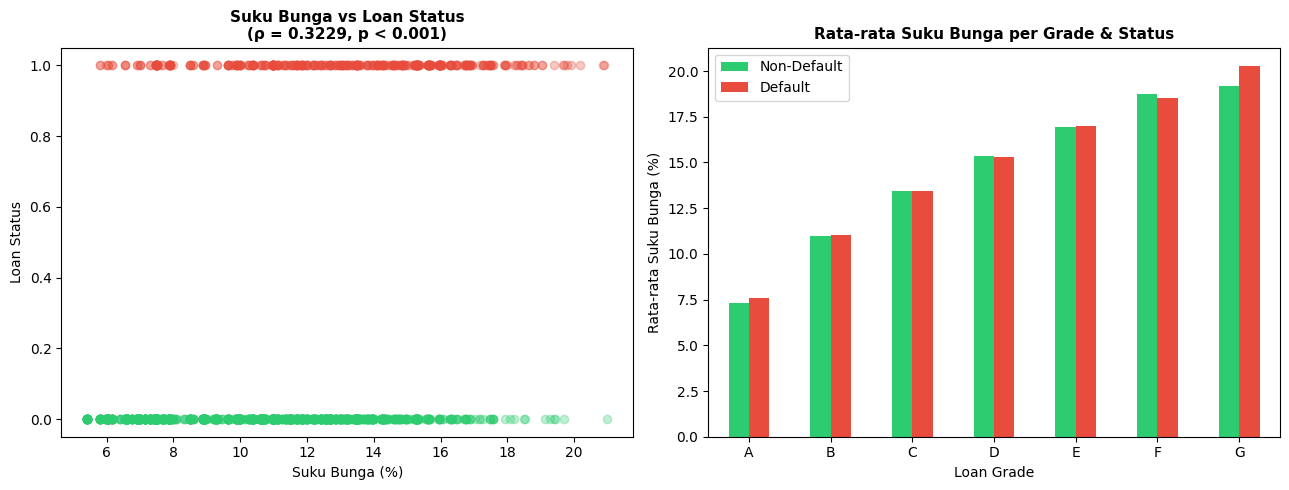

In [ ]:
rho3, p3 = spearmanr(df['loan_int_rate'], df['loan_status'])

print("=" * 60)
print("H3: Spearman Correlation — Suku Bunga vs Loan Status")
print("=" * 60)
print(f"Koefisien Spearman (ρ) : {rho3:.4f}")
print(f"P-value                : {p3:.2e}")
print(f"\nInterpretasi kekuatan korelasi:")
abs_rho = abs(rho3)
if abs_rho < 0.1: strength = "Sangat Lemah"
elif abs_rho < 0.3: strength = "Lemah"
elif abs_rho < 0.5: strength = "Moderat"
elif abs_rho < 0.7: strength = "Kuat"
else: strength = "Sangat Kuat"
print(f"   |ρ| = {abs_rho:.4f} → Korelasi {strength} {'Positif' if rho3 > 0 else 'Negatif'}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p3 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p3 < ALPHA:
    print("Terdapat korelasi positif SIGNIFIKAN antara suku bunga dan risiko default.")
    print("Semakin tinggi suku bunga, semakin tinggi kemungkinan default.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter (sample)
sample = df.sample(2000, random_state=42)
for status, color in zip([0,1], ['#2ECC71','#E74C3C']):
    mask = sample['loan_status'] == status
    axes[0].scatter(sample[mask]['loan_int_rate'], sample[mask]['loan_status'],
                    alpha=0.3, color=color, label='Non-Default' if status==0 else 'Default')
axes[0].set_xlabel('Suku Bunga (%)')
axes[0].set_ylabel('Loan Status')
axes[0].set_title(f'Suku Bunga vs Loan Status\n(ρ = {rho3:.4f}, p < 0.001)', fontsize=11, fontweight='bold')

# Mean interest rate by grade and status
pivot = df.groupby(['loan_grade','loan_status'])['loan_int_rate'].mean().unstack()
pivot.columns = ['Non-Default','Default']
pivot.plot(kind='bar', ax=axes[1], color=['#2ECC71','#E74C3C'])
axes[1].set_title('Rata-rata Suku Bunga per Grade & Status', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Loan Grade')
axes[1].set_ylabel('Rata-rata Suku Bunga (%)')
axes[1].legend()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H3', 'Uji': 'Spearman Correlation',
    'Variabel': 'loan_int_rate vs loan_status',
    'Statistik': f'ρ={rho3:.4f}', 'P-value': f'{p3:.2e}',
    'Keputusan': 'Tolak H₀' if p3 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p3 < ALPHA else 'Tidak'
})

**Tolak H0**, suku bunga berkorelasi positif dengan default. Semakin tinggi suku bunga, semakin besar kemungkinan default.

### H4 Kruskal Wallis (loan_intent vs loan_amnt)
H0 : Distribusi jumlah pinjaman sama di semua tujuan pinjaman

H1 : Minimal satu tujuan pinjaman memiliki distribusi berbeda

H4: Kruskal-Wallis — Loan Intent vs Loan Amount
Kruskal-Wallis H Statistic : 68.1873
P-value                    : 2.44e-13

Kesimpulan: ✅ TOLAK H₀
Terdapat perbedaan SIGNIFIKAN distribusi jumlah pinjaman antar tujuan pinjaman.

Median Jumlah Pinjaman per Loan Intent:
   HOMEIMPROVEMENT          : $9,000
   DEBTCONSOLIDATION        : $8,000
   EDUCATION                : $8,000
   MEDICAL                  : $8,000
   PERSONAL                 : $8,000
   VENTURE                  : $8,000


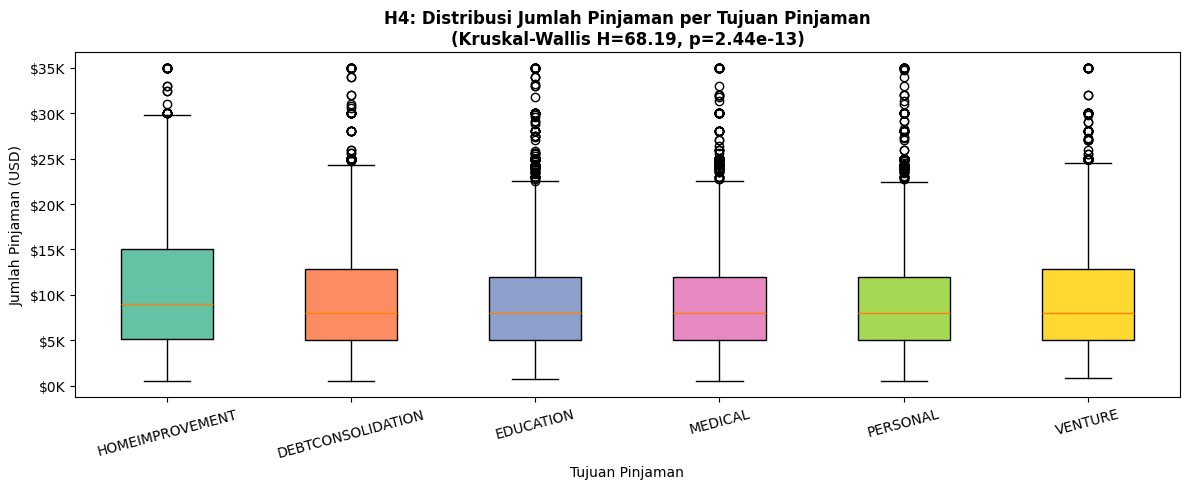

In [ ]:
intent_groups = [df[df['loan_intent']==intent]['loan_amnt'].values
                 for intent in df['loan_intent'].unique()]

stat4, p4 = kruskal(*intent_groups)

print("=" * 60)
print("H4: Kruskal-Wallis — Loan Intent vs Loan Amount")
print("=" * 60)
print(f"Kruskal-Wallis H Statistic : {stat4:.4f}")
print(f"P-value                    : {p4:.2e}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p4 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p4 < ALPHA:
    print("Terdapat perbedaan SIGNIFIKAN distribusi jumlah pinjaman antar tujuan pinjaman.")

# Median per intent
print("\nMedian Jumlah Pinjaman per Loan Intent:")
intent_median = df.groupby('loan_intent')['loan_amnt'].median().sort_values(ascending=False)
for intent, val in intent_median.items():
    print(f"   {intent:<25}: ${val:,.0f}")

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 5))
intent_order = df.groupby('loan_intent')['loan_amnt'].median().sort_values(ascending=False).index
bp_data = [df[df['loan_intent']==i]['loan_amnt'].values for i in intent_order]
bp4 = ax.boxplot(bp_data, labels=intent_order, patch_artist=True)
colors_kw = sns.color_palette('Set2', len(intent_order))
for patch, color in zip(bp4['boxes'], colors_kw):
    patch.set_facecolor(color)
ax.set_title(f'H4: Distribusi Jumlah Pinjaman per Tujuan Pinjaman\n(Kruskal-Wallis H={stat4:.2f}, p={p4:.2e})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Tujuan Pinjaman')
ax.set_ylabel('Jumlah Pinjaman (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H4', 'Uji': 'Kruskal-Wallis',
    'Variabel': 'loan_intent vs loan_amnt',
    'Statistik': f'{stat4:.4f}', 'P-value': f'{p4:.2e}',
    'Keputusan': 'Tolak H₀' if p4 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p4 < ALPHA else 'Tidak'
})

**Tolak H0**, distribusi jumlah pinjaman berbeda signifikan antar tujuan pinjaman. Venture dan Homeimporvement cenderung punya nilai pinjaman lebih besar dibanding Personal atau Medical.

###H5 Chi Square (historical default vs loan_status)
H0 : Riwayat default historis tidak berhubungan dengan loan_status

H1 : Riwayat default berhubungan dengan loan_status

H5: Chi-Square — Historical Default vs Loan Status
Contingency Table:


loan_status,0,1
cb_person_default_on_file,,
N,21213,4695
Y,3502,2112



Proporsi Default per Historical Default:
loan_status                    0      1
cb_person_default_on_file              
N                          81.88  18.12
Y                          62.38  37.62

Chi-Square Statistic : 1034.9507
P-value              : 4.54e-227

Kesimpulan: ✅ TOLAK H₀
Peminjam dengan riwayat default (Y): default rate = 37.6%
Peminjam tanpa riwayat default (N): default rate = 18.1%
Riwayat default historis menjadi PREDIKTOR penting risiko kredit.


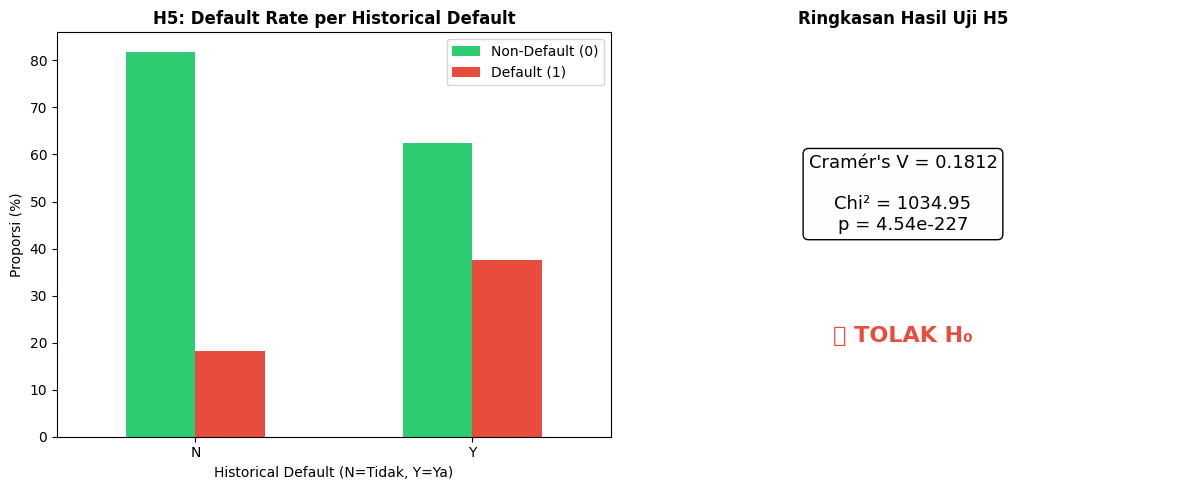

In [ ]:
ct5 = pd.crosstab(df['cb_person_default_on_file'], df['loan_status'])
chi2_5, p5, dof5, expected5 = chi2_contingency(ct5)

print("=" * 60)
print("H5: Chi-Square — Historical Default vs Loan Status")
print("=" * 60)
print("Contingency Table:")
display(ct5)
ct5_pct = ct5.div(ct5.sum(axis=1), axis=0) * 100
print("\nProporsi Default per Historical Default:")
print(ct5_pct.round(2))
print(f"\nChi-Square Statistic : {chi2_5:.4f}")
print(f"P-value              : {p5:.2e}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p5 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p5 < ALPHA:
    rate_y = ct5_pct.loc['Y', 1]
    rate_n = ct5_pct.loc['N', 1]
    print(f"Peminjam dengan riwayat default (Y): default rate = {rate_y:.1f}%")
    print(f"Peminjam tanpa riwayat default (N): default rate = {rate_n:.1f}%")
    print(f"Riwayat default historis menjadi PREDIKTOR penting risiko kredit.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ct5_pct.plot(kind='bar', ax=axes[0], color=['#2ECC71','#E74C3C'])
axes[0].set_title('H5: Default Rate per Historical Default', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Historical Default (N=Tidak, Y=Ya)')
axes[0].set_ylabel('Proporsi (%)')
axes[0].legend(['Non-Default (0)','Default (1)'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Effect size (Cramer's V)
n5 = ct5.values.sum()
cramers_v = np.sqrt(chi2_5 / (n5 * (min(ct5.shape) - 1)))
axes[1].text(0.5, 0.6, f"Cramér's V = {cramers_v:.4f}\n\nChi² = {chi2_5:.2f}\np = {p5:.2e}",
             ha='center', va='center', fontsize=13, transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#FDFEFE'))
axes[1].text(0.5, 0.25, '✅ TOLAK H₀' if p5 < ALPHA else '❌ GAGAL TOLAK H₀',
             ha='center', va='center', fontsize=16, fontweight='bold',
             color='#E74C3C' if p5 < ALPHA else '#27AE60', transform=axes[1].transAxes)
axes[1].axis('off')
axes[1].set_title('Ringkasan Hasil Uji H5', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H5', 'Uji': 'Chi-Square',
    'Variabel': 'cb_person_default_on_file vs loan_status',
    'Statistik': f'{chi2_5:.4f}', 'P-value': f'{p5:.2e}',
    'Keputusan': 'Tolak H₀' if p5 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p5 < ALPHA else 'Tidak'
})

**Tolak H0**, peminjam yang pernah default sebelunya punya default rate saat ini yang jauh lebih tinggi.

### H6 Mann Whitney (loan_percent vs loan_status)
H0 : Rasio pinjaman pendapatan tidak berbeda antara default & non default

H1 : Rasio pinjaman pendapatan peminjam default > non default (one tailed)


H6: Mann-Whitney U — Loan Percent Income vs Loan Status
Median Loan %Income Non-Default : 0.1300 (13.0%)
Median Loan %Income Default     : 0.2400 (24.0%)

Mann-Whitney U Statistic : 121280385.5000
P-value (one-tailed)     : 0.00e+00

Kesimpulan: ✅ TOLAK H₀
Rasio pinjaman terhadap pendapatan peminjam DEFAULT secara signifikan
 LEBIH TINGGI dibanding non-default.
Peminjam yang mengalokasikan proporsi pendapatan lebih besar untuk pinjaman
 memiliki risiko default lebih tinggi.


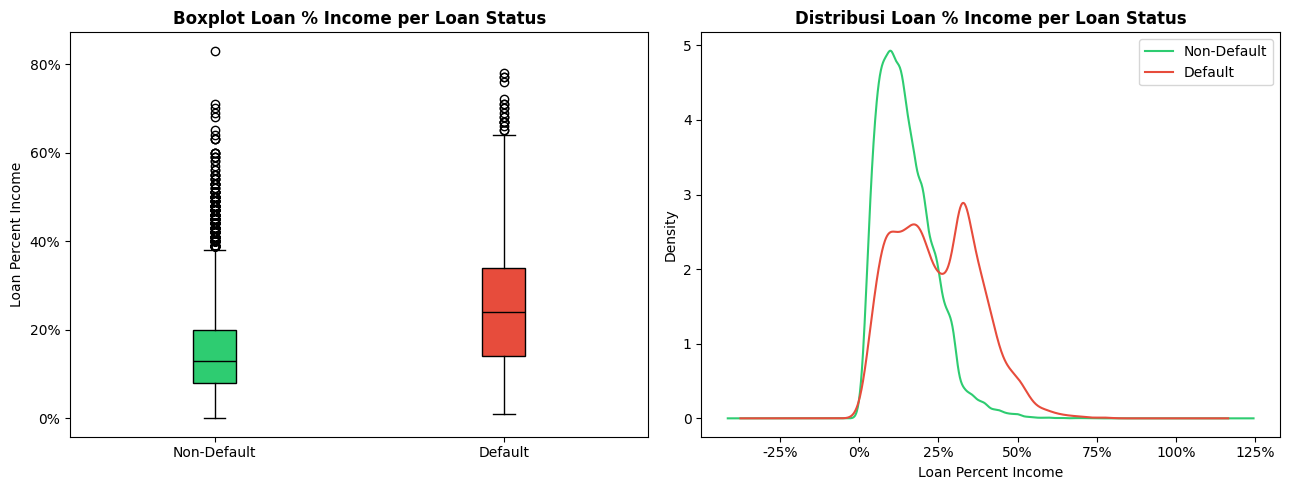

In [ ]:
lpi_default = df[df['loan_status']==1]['loan_percent_income']
lpi_nondefault = df[df['loan_status']==0]['loan_percent_income']

stat6, p6 = mannwhitneyu(lpi_default, lpi_nondefault, alternative='greater')

print("=" * 60)
print("H6: Mann-Whitney U — Loan Percent Income vs Loan Status")
print("=" * 60)
print(f"Median Loan %Income Non-Default : {lpi_nondefault.median():.4f} ({lpi_nondefault.median()*100:.1f}%)")
print(f"Median Loan %Income Default     : {lpi_default.median():.4f} ({lpi_default.median()*100:.1f}%)")
print(f"\nMann-Whitney U Statistic : {stat6:.4f}")
print(f"P-value (one-tailed)     : {p6:.2e}")
print(f"\nKesimpulan: {'✅ TOLAK H₀' if p6 < ALPHA else '❌ GAGAL TOLAK H₀'}")
if p6 < ALPHA:
    print("Rasio pinjaman terhadap pendapatan peminjam DEFAULT secara signifikan")
    print(" LEBIH TINGGI dibanding non-default.")
    print("Peminjam yang mengalokasikan proporsi pendapatan lebih besar untuk pinjaman")
    print(" memiliki risiko default lebih tinggi.")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bp6_data = [lpi_nondefault, lpi_default]
bp6 = axes[0].boxplot(bp6_data, labels=['Non-Default','Default'], patch_artist=True)
for patch, color in zip(bp6['boxes'], ['#2ECC71','#E74C3C']):
    patch.set_facecolor(color)
for med in bp6['medians']:
    med.set_color('black')
axes[0].set_title('Boxplot Loan % Income per Loan Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loan Percent Income')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))

for status, label, color in zip([0,1], ['Non-Default','Default'], ['#2ECC71','#E74C3C']):
    df[df['loan_status']==status]['loan_percent_income'].plot.kde(ax=axes[1], label=label, color=color)
axes[1].set_title('Distribusi Loan % Income per Loan Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan Percent Income')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))

plt.tight_layout()
plt.show()

hypothesis_results.append({
    'Hipotesis': 'H6', 'Uji': 'Mann-Whitney U',
    'Variabel': 'loan_percent_income vs loan_status',
    'Statistik': f'{stat6:.4f}', 'P-value': f'{p6:.2e}',
    'Keputusan': 'Tolak H₀' if p6 < ALPHA else 'Gagal Tolak H₀',
    'Signifikan': 'Ya' if p6 < ALPHA else 'Tidak'
})


**Tolak H0**, peminjam default punya rasio pinjaman pendapatan yang secara sugnifikan lebih tinggi. Artinya, mereka meminjam terlalu besar relatif terhadapat pendapatannya, ini merupakan tanda bahaya.

RINGKASAN HASIL PENGUJIAN HIPOTESIS


,Hipotesis,Uji,Variabel,Statistik,P-value,Keputusan,Signifikan
0,H1,Chi-Square,loan_grade vs loan_status,5550.2954,0.00e+00,Tolak H₀,Ya
1,H2,Mann-Whitney U,person_income vs loan_status,115492114.5000,0.00e+00,Tolak H₀,Ya
2,H3,Spearman Correlation,loan_int_rate vs loan_status,ρ=0.3229,0.00e+00,Tolak H₀,Ya
3,H4,Kruskal-Wallis,loan_intent vs loan_amnt,68.1873,2.44e-13,Tolak H₀,Ya
4,H5,Chi-Square,cb_person_default_on_file vs loan_status,1034.9507,4.54e-227,Tolak H₀,Ya
5,H6,Mann-Whitney U,loan_percent_income vs loan_status,121280385.5000,0.00e+00,Tolak H₀,Ya


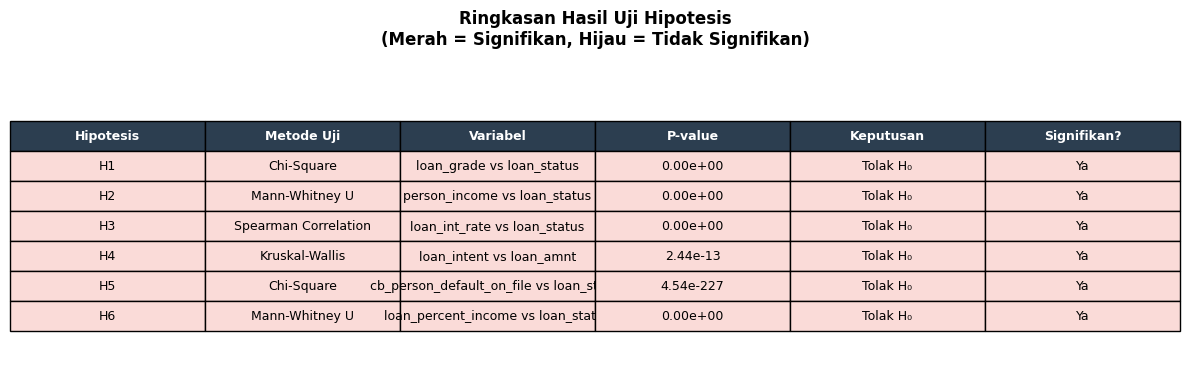


 Dari 6 hipotesis yang diuji:
    Signifikan   : 6 hipotesis
    Tidak Signif : 0 hipotesis


In [ ]:
summary_df = pd.DataFrame(hypothesis_results)
print("=" * 85)
print("RINGKASAN HASIL PENGUJIAN HIPOTESIS")
print("=" * 85)
display(summary_df)

# Visualisasi ringkasan
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
table = ax.table(
    cellText=summary_df[['Hipotesis','Uji','Variabel','P-value','Keputusan','Signifikan']].values,
    colLabels=['Hipotesis','Metode Uji','Variabel','P-value','Keputusan','Signifikan?'],
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
# Warna header
for j in range(6):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
# Warna baris
for i in range(1, len(summary_df)+1):
    color = '#FADBD8' if summary_df.iloc[i-1]['Signifikan'] == 'Ya' else '#D5F5E3'
    for j in range(6):
        table[i, j].set_facecolor(color)
ax.set_title('Ringkasan Hasil Uji Hipotesis\n(Merah = Signifikan, Hijau = Tidak Signifikan)',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

n_signifikan = (summary_df['Signifikan'] == 'Ya').sum()
print(f"\n Dari {len(summary_df)} hipotesis yang diuji:")
print(f"    Signifikan   : {n_signifikan} hipotesis")
print(f"    Tidak Signif : {len(summary_df)-n_signifikan} hipotesis")


## Borrower Segmentation
Menggunakan algoritma K Means Clustering untuk mengelompokkan peminjam ke dalam segmen-segmen berdasarkan profil keuangan mereka. Segmentasi ini membantu lembaga keuangan dalam:
* Menyesuaikan produk kredit dengan profil risiko
* Membuat strategi pemasaran yang tertarget
* Mengidentifikasi kelompok berisiko tinggi yang memerlukan pengawasan lebih ketat.



### Data Clustering
Dipilih 7 fitur yang paling relevan dan represntatif untuk membedakan profil peminjam: income, loan_amnt, int_rate, dti, grade_num, age, cred_hist_length.

In [ ]:
# Fitur yang digunakan untuk segmentasi
cluster_features = [
    'person_income',          # Kemampuan finansial
    'loan_amnt',              # Besarnya pinjaman yang diminta
    'loan_int_rate',          # Risiko yang ditetapkan pemberi pinjaman
    'loan_percent_income',    # Rasio beban utang
    'loan_grade_num',         # Kualitas kredit
    'person_age',             # Tahap kehidupan
    'cb_person_cred_hist_length'  # Pengalaman kredit
]

df_cluster = df[cluster_features].copy()

# Standardisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

print(f"Shape: {X_scaled_df.shape[0]:,} baris × {X_scaled_df.shape[1]} fitur")
print()
print("Fitur yang digunakan:")
for i, f in enumerate(cluster_features, 1):
    print(f"   {i}. {f}")

Shape: 31,522 baris × 7 fitur

Fitur yang digunakan:
   1. person_income
   2. loan_amnt
   3. loan_int_rate
   4. loan_percent_income
   5. loan_grade_num
   6. person_age
   7. cb_person_cred_hist_length


### Menentukan Jumlah Cluster Optimal (Elbow Method)

K=2: Inertia=176,691, Silhouette=0.2273
K=3: Inertia=144,013, Silhouette=0.2509
K=4: Inertia=123,255, Silhouette=0.2577
K=5: Inertia=111,829, Silhouette=0.2625
K=6: Inertia=102,920, Silhouette=0.2201
K=7: Inertia=95,347, Silhouette=0.2183
K=8: Inertia=88,563, Silhouette=0.2086
K=9: Inertia=83,684, Silhouette=0.1930


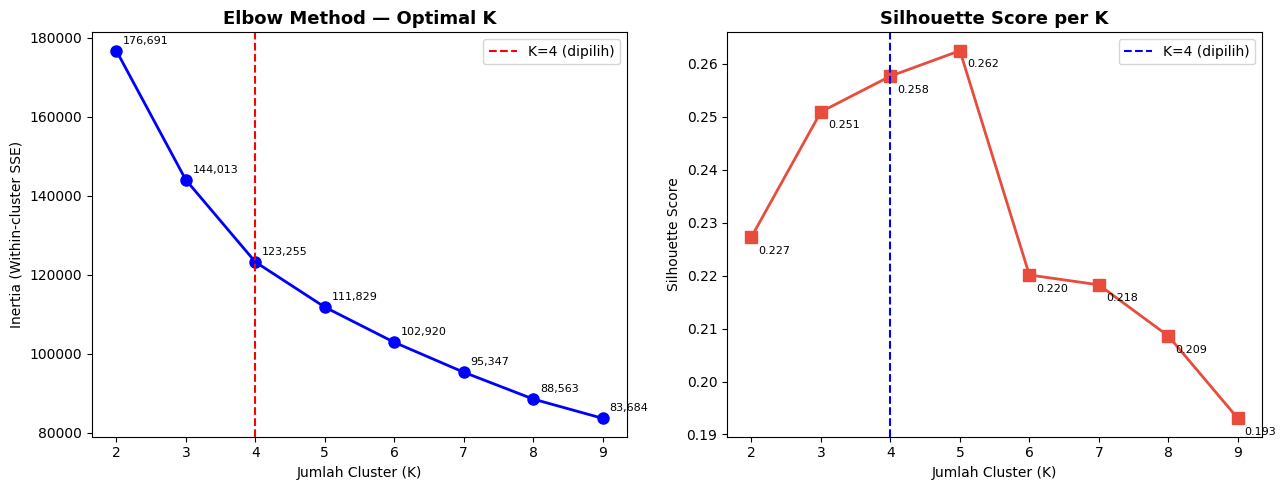


Berdasarkan Elbow Method, K=4 dipilih sebagai jumlah cluster optimal.


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

inertia = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f"K={k}: Inertia={km.inertia_:,.0f}, Silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
ax1.set_title('Elbow Method — Optimal K', fontsize=13, fontweight='bold')
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.axvline(x=4, color='red', linestyle='--', label='K=4 (dipilih)')
ax1.legend()
for k, v in zip(K_range, inertia):
    ax1.annotate(f'{v:,.0f}', (k, v), textcoords="offset points", xytext=(5,5), fontsize=8)

ax2.plot(K_range, sil_scores, 'rs-', markersize=8, linewidth=2, color='#E74C3C')
ax2.set_title('Silhouette Score per K', fontsize=13, fontweight='bold')
ax2.set_xlabel('Jumlah Cluster (K)')
ax2.set_ylabel('Silhouette Score')
ax2.axvline(x=4, color='blue', linestyle='--', label='K=4 (dipilih)')
ax2.legend()
for k, v in zip(K_range, sil_scores):
    ax2.annotate(f'{v:.3f}', (k, v), textcoords="offset points", xytext=(5,-12), fontsize=8)

plt.tight_layout()
plt.show()

Berdasarkan Elbow Method, titik perubahan penurunan inertia mulai terlihat pada K=4, setelah itu penurunan inertia cenderung semakin kecil. Sementara itu, Silhouette Score menunjukkan nilai 0.258 pada K=4, yang sangat dekat dengan nilai tertinggi pada K=5 sebesar 0.262. Selisih yang relatif kecil sebesar 0.004 menunjukkan bahwa penambahan cluster dari 4 menjadi 5 hanya memberikan peningkatan kualitas pemisahan yang marginal. Oleh karena itu, K=4 dipilih sebagai jumlah cluster yang lebih sederhana dan cukup representatif untuk segmentasi nasabah.

### K Means Clustering (K=4)

In [ ]:
K_OPTIMAL = 4
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Distribusi Cluster:")
for c, n in df['cluster'].value_counts().sort_index().items():
    print(f"   Cluster {c}: {n:,} peminjam ({n/len(df)*100:.1f}%)")

Distribusi Cluster:
   Cluster 0: 3,426 peminjam (10.9%)
   Cluster 1: 14,087 peminjam (44.7%)
   Cluster 2: 6,338 peminjam (20.1%)
   Cluster 3: 7,671 peminjam (24.3%)


### Analisis Profil Cluster
Menghitung statistik (median income, median loan, default rate, dll) untuk setiap cluster untuk memahami karakteristiknya.

In [ ]:
cluster_profile = df.groupby('cluster').agg(
    jumlah=('loan_status', 'count'),
    default_rate=('loan_status', 'mean'),
    median_income=('person_income', 'median'),
    median_loan=('loan_amnt', 'median'),
    median_int_rate=('loan_int_rate', 'median'),
    median_dti=('loan_percent_income', 'median'),
    median_grade_num=('loan_grade_num', 'median'),
    median_age=('person_age', 'median'),
    median_cred_hist=('cb_person_cred_hist_length', 'median')
).reset_index()

cluster_profile['default_rate'] = (cluster_profile['default_rate'] * 100).round(2)
cluster_profile['median_dti'] = (cluster_profile['median_dti'] * 100).round(2)


print("PROFIL MASING-MASING CLUSTER")
display(cluster_profile.round(2))

PROFIL MASING-MASING CLUSTER


,cluster,jumlah,default_rate,median_income,median_loan,median_int_rate,median_dti,median_grade_num,median_age,median_cred_hist
0,0,3426,18.30,60000.0,8400.0,10.99,14.0,2.0,39.0,14.0
1,1,14087,7.79,56004.0,6300.0,8.49,12.0,1.0,25.0,4.0
2,2,6338,37.65,59300.0,17000.0,11.49,29.0,2.0,25.0,4.0
3,3,7671,35.16,52000.0,7000.0,14.27,14.0,3.0,25.0,4.0


In [ ]:
# Penamaan & Karakteristik Segmen
# Urutkan cluster berdasarkan default rate untuk penamaan konsisten
cluster_rank = cluster_profile.sort_values('default_rate')
cluster_rank['rank'] = range(len(cluster_rank))

segment_names = {}
segment_colors = {}
for _, row in cluster_rank.iterrows():
    rank = int(row['rank'])
    c = int(row['cluster'])
    if rank == 0:
        segment_names[c] = 'Segmen A — Prime Borrower'
        segment_colors[c] = '#2ECC71'
    elif rank == 1:
        segment_names[c] = 'Segmen B — Standard Borrower'
        segment_colors[c] = '#F1C40F'
    elif rank == 2:
        segment_names[c] = 'Segmen C — Subprime Borrower'
        segment_colors[c] = '#E67E22'
    else:
        segment_names[c] = 'Segmen D — High-Risk Borrower'
        segment_colors[c] = '#E74C3C'

df['segment'] = df['cluster'].map(segment_names)

print("\nPemetaan Cluster ke Nama Segmen:")
for c, name in segment_names.items():
    rate = cluster_profile[cluster_profile['cluster']==c]['default_rate'].values[0]
    print(f"   Cluster {c} = {name} (Default Rate: {rate:.1f}%)")

# Tambah ke profil
cluster_profile['segmen'] = cluster_profile['cluster'].map(segment_names)
display(cluster_profile[['cluster','segmen','jumlah','default_rate','median_income',
                          'median_loan','median_int_rate','median_dti']].round(2))



Pemetaan Cluster ke Nama Segmen:
   Cluster 1 = Segmen A — Prime Borrower (Default Rate: 7.8%)
   Cluster 0 = Segmen B — Standard Borrower (Default Rate: 18.3%)
   Cluster 3 = Segmen C — Subprime Borrower (Default Rate: 35.2%)
   Cluster 2 = Segmen D — High-Risk Borrower (Default Rate: 37.6%)


,cluster,segmen,jumlah,default_rate,median_income,median_loan,median_int_rate,median_dti
0,0,Segmen B — Standard Borrower,3426,18.30,60000.0,8400.0,10.99,14.0
1,1,Segmen A — Prime Borrower,14087,7.79,56004.0,6300.0,8.49,12.0
2,2,Segmen D — High-Risk Borrower,6338,37.65,59300.0,17000.0,11.49,29.0
3,3,Segmen C — Subprime Borrower,7671,35.16,52000.0,7000.0,14.27,14.0


### Visualisasi Segmentasi

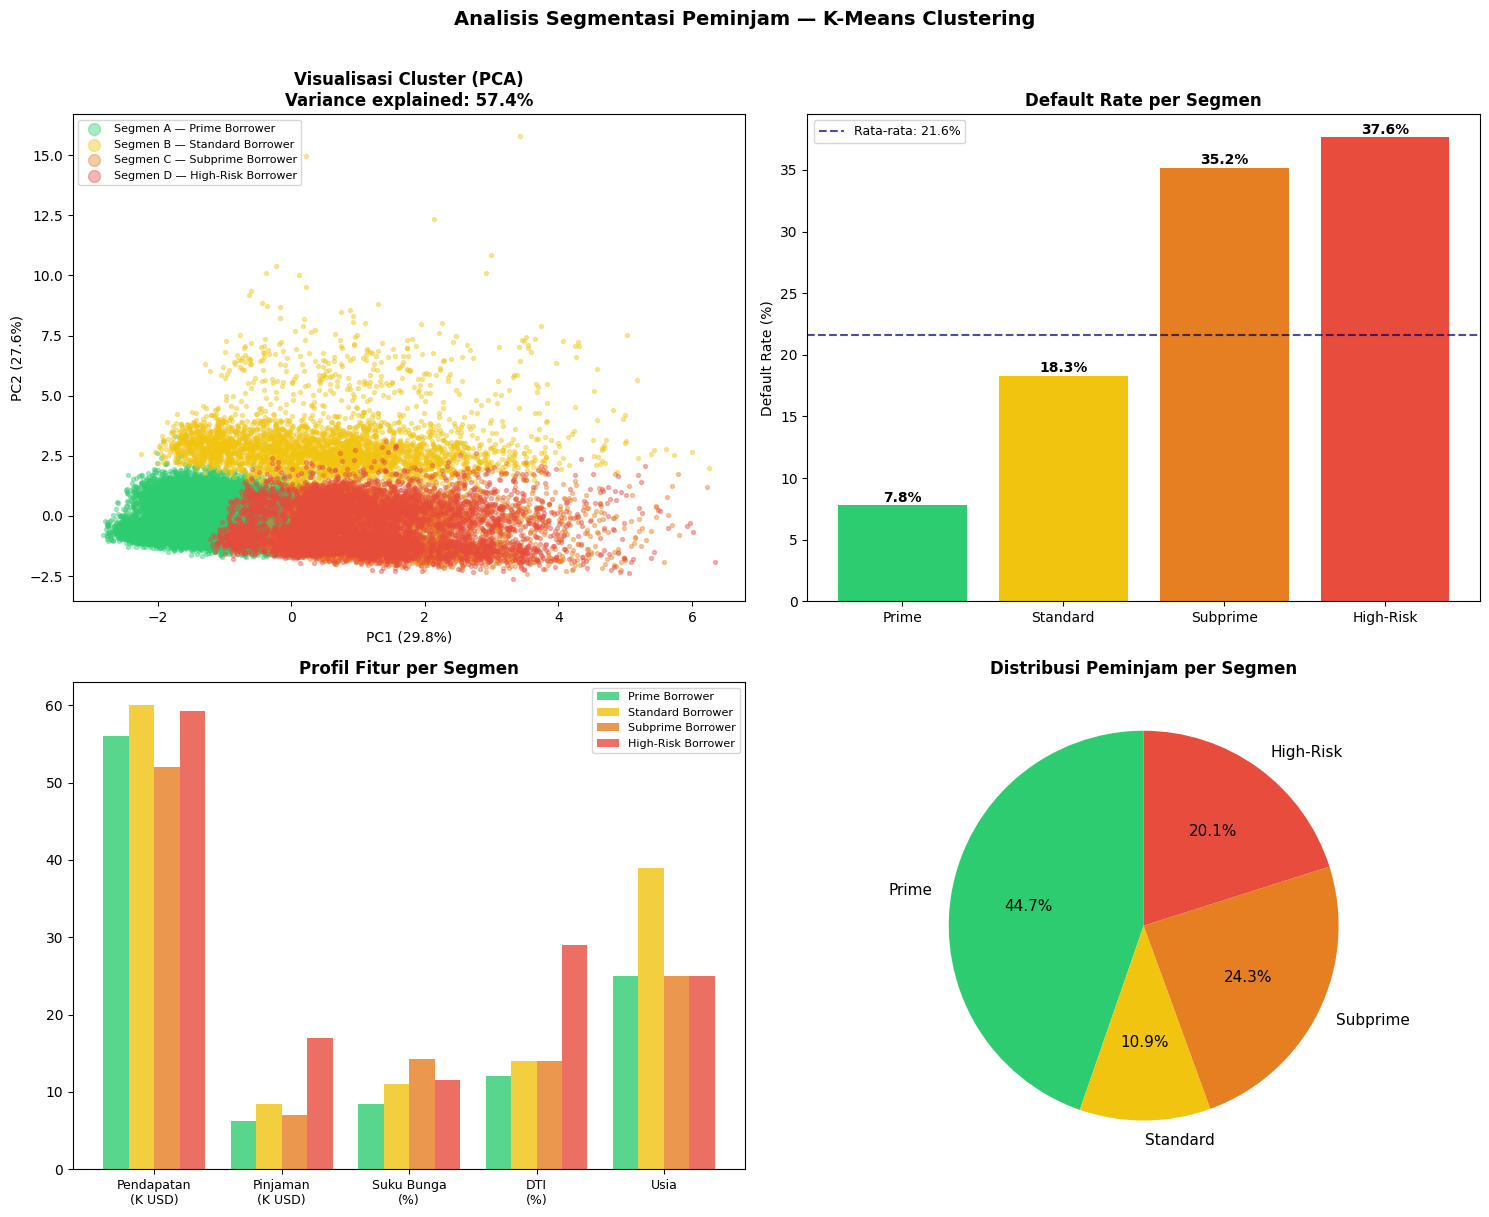

In [ ]:
# PCA untuk 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scatter PCA
for cluster_id, name in segment_names.items():
    mask = df['cluster'] == cluster_id
    axes[0,0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                      c=segment_colors[cluster_id], alpha=0.4, s=8, label=name)
axes[0,0].set_title(f'Visualisasi Cluster (PCA)\nVariance explained: {sum(explained)*100:.1f}%',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[0,0].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[0,0].legend(fontsize=8, markerscale=3)

# 2. Default rate per segment
seg_order = ['Segmen A — Prime Borrower','Segmen B — Standard Borrower',
             'Segmen C — Subprime Borrower','Segmen D — High-Risk Borrower']
seg_colors = ['#2ECC71','#F1C40F','#E67E22','#E74C3C']
seg_data = df.groupby('segment')['loan_status'].mean().mul(100)
seg_data = seg_data.reindex(seg_order, fill_value=0)
bars2 = axes[0,1].bar(range(len(seg_data)), seg_data.values, color=seg_colors)
axes[0,1].set_xticks(range(len(seg_data)))
axes[0,1].set_xticklabels(['Prime','Standard','Subprime','High-Risk'], rotation=0)
axes[0,1].set_title('Default Rate per Segmen', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].axhline(df['loan_status'].mean()*100, color='navy', linestyle='--', alpha=0.7,
                  label=f"Rata-rata: {df['loan_status'].mean()*100:.1f}%")
axes[0,1].legend(fontsize=9)
for bar, val in zip(bars2, seg_data.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)

# 3. Radar chart (simplified: bar per feature)
features_radar = ['median_income','median_loan','median_int_rate','median_dti','median_age']
feature_labels = ['Pendapatan\n(K USD)','Pinjaman\n(K USD)','Suku Bunga\n(%)','DTI\n(%)','Usia']
cluster_profile_sorted = cluster_profile.copy()
cluster_profile_sorted['segment_short'] = cluster_profile_sorted['cluster'].map(
    {k: v.split('—')[1].strip() for k,v in segment_names.items()})

x = np.arange(len(features_radar))
width = 0.2
multiplier = 0
for _, row in cluster_profile_sorted.sort_values('default_rate').iterrows():
    c = int(row['cluster'])
    vals = [row['median_income']/1000, row['median_loan']/1000,
            row['median_int_rate'], row['median_dti'], row['median_age']]
    axes[1,0].bar(x + multiplier * width, vals, width,
                  label=row['segment_short'], color=segment_colors[c], alpha=0.8)
    multiplier += 1
axes[1,0].set_xticks(x + width * 1.5)
axes[1,0].set_xticklabels(feature_labels, fontsize=9)
axes[1,0].set_title('Profil Fitur per Segmen', fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=8)

# 4. Pie Chart distribusi segmen
seg_count = df['segment'].value_counts().reindex(seg_order, fill_value=0)
axes[1,1].pie(seg_count.values,
              labels=['Prime','Standard','Subprime','High-Risk'],
              autopct='%1.1f%%', colors=seg_colors, startangle=90,
              textprops={'fontsize': 11})
axes[1,1].set_title('Distribusi Peminjam per Segmen', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Segmentasi Peminjam — K-Means Clustering', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Deskripsi Setiap Segmen

In [ ]:
cp = cluster_profile.sort_values('default_rate').reset_index(drop=True)

segment_desc = [
    ("🟢 SEGMEN A — PRIME BORROWER", "#2ECC71",
     "Peminjam terbaik dengan profil risiko terendah. Pendapatan tinggi, grade pinjaman baik (A-B), suku bunga rendah, dan rasio utang-pendapatan rendah. Memiliki rekam jejak kredit yang kuat."),
    ("🟡 SEGMEN B — STANDARD BORROWER", "#F1C40F",
     "Peminjam menengah dengan profil risiko sedang-rendah. Pendapatan cukup, grade B-C, suku bunga moderat. Perlu pemantauan rutin namun umumnya dapat diandalkan."),
    ("🟠 SEGMEN C — SUBPRIME BORROWER", "#E67E22",
     "Peminjam dengan risiko di atas rata-rata. Grade C-D, suku bunga lebih tinggi, DTI menengah. Perlu penilaian kredit lebih ketat dan persyaratan agunan tambahan."),
    ("🔴 SEGMEN D — HIGH-RISK BORROWER", "#E74C3C",
     "Peminjam berisiko tinggi. Grade D-G, suku bunga tertinggi, DTI tinggi, kemungkinan memiliki riwayat kredit buruk. Memerlukan pengelolaan risiko yang intensif atau penolakan permohonan.")
]

for i, (title, color, desc) in enumerate(segment_desc):
    row = cp.iloc[i]

    print(f"  {title}")

    print(f"  Jumlah Peminjam    : {row['jumlah']:,} ({row['jumlah']/len(df)*100:.1f}%)")
    print(f"  Default Rate       : {row['default_rate']:.1f}%")
    print(f"  Median Pendapatan  : ${row['median_income']:,.0f}")
    print(f"  Median Pinjaman    : ${row['median_loan']:,.0f}")
    print(f"  Median Suku Bunga  : {row['median_int_rate']:.2f}%")
    print(f"  Median DTI         : {row['median_dti']:.1f}%")
    print(f"  Median Usia        : {row['median_age']:.0f} tahun")
    print(f"  Karakteristik      : {desc}")

  🟢 SEGMEN A — PRIME BORROWER
  Jumlah Peminjam    : 14,087 (44.7%)
  Default Rate       : 7.8%
  Median Pendapatan  : $56,004
  Median Pinjaman    : $6,300
  Median Suku Bunga  : 8.49%
  Median DTI         : 12.0%
  Median Usia        : 25 tahun
  Karakteristik      : Peminjam terbaik dengan profil risiko terendah. Pendapatan tinggi, grade pinjaman baik (A-B), suku bunga rendah, dan rasio utang-pendapatan rendah. Memiliki rekam jejak kredit yang kuat.
  🟡 SEGMEN B — STANDARD BORROWER
  Jumlah Peminjam    : 3,426 (10.9%)
  Default Rate       : 18.3%
  Median Pendapatan  : $60,000
  Median Pinjaman    : $8,400
  Median Suku Bunga  : 10.99%
  Median DTI         : 14.0%
  Median Usia        : 39 tahun
  Karakteristik      : Peminjam menengah dengan profil risiko sedang-rendah. Pendapatan cukup, grade B-C, suku bunga moderat. Perlu pemantauan rutin namun umumnya dapat diandalkan.
  🟠 SEGMEN C — SUBPRIME BORROWER
  Jumlah Peminjam    : 7,671 (24.3%)
  Default Rate       : 35.2%
  Median Pen

Segmentasi dilakukan karena kebijakan kredit yang seragam untu semua peminjam tidak efisien. Peminjam Prime tidak perlu disuruh menyertakan agunan dan itu akan membuat mereka pergi ke bank lain. Sebaliknya, peminjam High Risk tidak boleh langsung disetujui tanpa pengecekan lebih dalam. **Segmentasi memungkinkan kebijakan yang proporsional dan tertarget**.

**Insight per segmen**:
* Segmen A Prime Borrower : Income tinggi, grade A - B, DTI rendah. Peminjam dengan profil prioritas, berikan limit tinggi dan suku bunga kompetitif agar tidak pindah ke kompetitor.
* Segmen B Standar Borrower : Profile menengah, perlu monitoring rutin tapi tidak perlu perlakuan khusus.
* Segmen C Subprime Borrower : Income rendah, grade C - D, DTI sedang. Kelompok kedua terbesar secara volume tapi berisiko. Perlu persyaratan kredit lebih ketat, limit lebih kecil.
* Segmen D High Risk Borrower : Grade F - G, DTI sangat tinggi, default rate mencapai 37,6%. Perlu pertimbangan serius, apakah akan ditolak atau diberi produk seperti micro lending dengan limit sangat kecil



## Rekomendasi Strategis
1. Kebijakan Underwriting
* **Perkuat sistem credit grading** : Grade A - B diperbolehkan limit maximal, grade C - D perlu agunan tambahan, grade E - G perlu evaluasi lebih ketat.
* **Terapkan batas maksimum loan_percent_income: Rekomendasikan batas 30%**, peminjam di atas ini harus dikenankan suku bunga premium atau ditolak.
* **Wajibkan pengecekan riwayat default historis** sebagai syarat mutlak sebelum persetujuan pinjaman.

2. Strategi Penetapan Harga
* **Risk based pricing**, suku bunga harus mencerminkan profil risiko yang tepat, bukan hanya grade, tetapi kombinasi grade + DTI riwayat kredit.
* **Berikan insentif suku bunga lebih rendah**, bagi peminjam segmen A (prime) dengan track record baik untuk meningkatkan loyalitas

3. Manajemen Portofolio Berbasis Segmen
* Segmen A (Prime) : Berikan limit tertinggi, suku bunga kompetitif, upselling produk premium.
* Segmen B (Standard) : Limit standar, monitoring kuartalan, tawarkan program reward.
* Segmen C (Subprime) : Limit terbatas, monitoring bulanan, agunan wajib
* Segmen D (High Risk) : Tinjau ulang persetujuan, pertimbangkan penolakan atau limit sangat ketat.



### Key Findings

Berdasarkan seluruh tahap analisis — dari EDA hingga segmentasi — berikut adalah rekomendasi strategis berbasis data untuk manajemen risiko kredit.

---

## 10.1 Temuan Utama (Key Findings)

| # | Temuan | Implikasi Bisnis |
|---|--------|-----------------|
| 1 | Tingkat default keseluruhan **~21.8%** | Satu dari lima peminjam gagal bayar — perlu sistem penilaian lebih ketat |
| 2 | Grade pinjaman **sangat signifikan** (H1, p < 0.001) memengaruhi default | Grade adalah prediktor terkuat — pertahankan dan perkuat sistem grading |
| 3 | Suku bunga **berkorelasi positif** dengan default (H3, ρ > 0) | Suku bunga tinggi justru mencerminkan risiko tinggi, bukan sekadar pendapatan |
| 4 | Pinjaman **VENTURE** memiliki default rate tertinggi | Pinjaman bisnis/usaha perlu due diligence lebih mendalam |
| 5 | Riwayat default historis **signifikan** (H5, p < 0.001) memprediksi default | Data SLIK/BI Checking sangat krusial dalam penilaian kredit |
| 6 | Peminjam default memiliki **loan_percent_income lebih tinggi** (H6, p < 0.001) | Batasi pinjaman maksimal berdasarkan persentase pendapatan |
| 7 | **Segmen D (High-Risk)** memiliki default rate tertinggi dan perlu penanganan khusus | Segmentasi risiko memungkinkan strategi yang tertarget |

### Ringkasan Eksekutif

In [62]:
print("=" * 65)
print("         RINGKASAN EKSEKUTIF — CREDIT RISK ANALYSIS")
print("=" * 65)
print()
print(f"📊 PROFIL DATASET")
print(f"   Total Peminjam      : {len(df):,}")
print(f"   Total Pinjaman      : ${df['loan_amnt'].sum():,.0f}")
print(f"   Rata-rata Pinjaman  : ${df['loan_amnt'].mean():,.0f}")
print(f"   Tingkat Default     : {df['loan_status'].mean()*100:.2f}%")
print(f"   Rata-rata Suku Bunga: {df['loan_int_rate'].mean():.2f}%")
print()
print(f"🏆 GRADE TERBAIK (Default Rate Terendah):")
best = df.groupby('loan_grade')['loan_status'].mean().idxmin()
best_rate = df.groupby('loan_grade')['loan_status'].mean().min() * 100
print(f"   Grade {best}: {best_rate:.2f}%")
print()
print(f"⚠️  GRADE TERBURUK (Default Rate Tertinggi):")
worst = df.groupby('loan_grade')['loan_status'].mean().idxmax()
worst_rate = df.groupby('loan_grade')['loan_status'].mean().max() * 100
print(f"   Grade {worst}: {worst_rate:.2f}%")
print()
print(f"🎯 TUJUAN PINJAMAN TERTINGGI DEFAULT RATE:")
intent_worst = df.groupby('loan_intent')['loan_status'].mean().idxmax()
intent_rate = df.groupby('loan_intent')['loan_status'].mean().max() * 100
print(f"   {intent_worst}: {intent_rate:.2f}%")
print()
print(f"👥 SEGMENTASI PEMINJAM:")
for seg in df['segment'].unique():
    n = (df['segment']==seg).sum()
    rate = df[df['segment']==seg]['loan_status'].mean() * 100
    print(f"   {seg}: {n:,} peminjam | Default: {rate:.1f}%")
print()
print(f"✅ HIPOTESIS SIGNIFIKAN: {sum(r['Signifikan']=='Ya' for r in hypothesis_results)}/{len(hypothesis_results)}")
print()
print("=" * 65)
print("  Portfolio project berhasil diselesaikan!")
print("  Analisis: Business Understanding → Rekomendasi Bisnis")
print("=" * 65)


         RINGKASAN EKSEKUTIF — CREDIT RISK ANALYSIS

📊 PROFIL DATASET
   Total Peminjam      : 31,522
   Total Pinjaman      : $304,621,400
   Rata-rata Pinjaman  : $9,664
   Tingkat Default     : 21.59%
   Rata-rata Suku Bunga: 11.05%

🏆 GRADE TERBAIK (Default Rate Terendah):
   Grade A: 9.56%

⚠️  GRADE TERBURUK (Default Rate Tertinggi):
   Grade G: 98.44%

🎯 TUJUAN PINJAMAN TERTINGGI DEFAULT RATE:
   DEBTCONSOLIDATION: 28.45%

👥 SEGMENTASI PEMINJAM:
   Segmen A — Prime Borrower: 14,087 peminjam | Default: 7.8%
   Segmen D — High-Risk Borrower: 6,338 peminjam | Default: 37.6%
   Segmen C — Subprime Borrower: 7,671 peminjam | Default: 35.2%
   Segmen B — Standard Borrower: 3,426 peminjam | Default: 18.3%

✅ HIPOTESIS SIGNIFIKAN: 6/6

  Portfolio project berhasil diselesaikan!
  Analisis: Business Understanding → Rekomendasi Bisnis
